# 📈 Advanced SPY Stock Forecasting with Macroeconomic Indicators

## Project Overview
This project predicts SPY (S&P 500 ETF) stock prices using a comprehensive approach that combines:
- **Technical indicators** (moving averages, RSI, volatility measures)
- **Macroeconomic indicators** (GDP, unemployment, inflation, interest rates)  
- **Market sentiment indicators** (VIX, sector performance)
- **Advanced machine learning models** (XGBoost, LightGBM, LSTM)

### Why Macroeconomic Indicators Matter:
- Stock markets are influenced by broader economic conditions
- Interest rates affect discount rates and valuations
- Inflation impacts real returns and monetary policy
- Employment data signals economic strength
- GDP growth drives corporate earnings expectations

In [55]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Date handling
from datetime import datetime, timedelta
import datetime as dt

# Data sources
import yfinance as yf
import pandas_datareader as pdr
from fredapi import Fred

# Machine learning
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Statistical analysis
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
import ta  # Technical analysis library

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"Pandas version: {pd.__version__}")

✅ All libraries imported successfully!
TensorFlow version: 2.20.0
Pandas version: 2.1.4


In [56]:
# Configuration and setup
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# FRED API setup (you'll need to get a free API key from https://fred.stlouisfed.org/docs/api/api_key.html)
# For demo purposes, we'll handle the case where no API key is available
try:
    # Replace 'your_fred_api_key_here' with your actual FRED API key
    fred = Fred(api_key='6721997ef0efd5d94a1b65dba6e5448e')
    FRED_AVAILABLE = True
    print("✅ FRED API configured successfully!")
except:
    FRED_AVAILABLE = False
    print("⚠️  FRED API not available - will use alternative data sources")

# Date range for analysis
START_DATE = '1990-01-01'
END_DATE = '2024-12-31'
PREDICTION_HORIZON = 1  # Predict 1 day ahead

# Data interval switch: 'daily' | 'monthly' | 'quarterly'
DATA_INTERVAL = 'daily'
INTERVAL_MAP = {'daily': 'D', 'monthly': 'M', 'quarterly': 'Q'}
INTERVAL_RULE = INTERVAL_MAP.get(DATA_INTERVAL, 'D')

print(f"📅 Analysis period: {START_DATE} to {END_DATE}")
print(f"🎯 Prediction horizon: {PREDICTION_HORIZON} day(s)")
print(f"⏱️ Using data interval: {DATA_INTERVAL} (rule={INTERVAL_RULE})")

✅ FRED API configured successfully!
📅 Analysis period: 1990-01-01 to 2024-12-31
🎯 Prediction horizon: 1 day(s)
⏱️ Using data interval: daily (rule=D)


## 1. Data Collection

### Data Sources:
1. **Stock Data**: Yahoo Finance (SPY ETF)
2. **Macroeconomic Data**: FRED (Federal Reserve Economic Data)
3. **Market Data**: VIX, sector ETFs, bond yields
4. **Alternative Sources**: When FRED API unavailable

In [57]:
def get_stock_data(symbol="SPY", start=START_DATE, end=END_DATE):
    """Download stock data with comprehensive error handling"""
    try:
        print(f"📊 Downloading {symbol} data from {start} to {end}...")
        data = yf.download(symbol, start=start, end=end, progress=False)
        
        if data.empty:
            raise ValueError(f"No data found for {symbol}")
            
        print(f"✅ Successfully downloaded {len(data)} days of {symbol} data")
        return data
    except Exception as e:
        print(f"❌ Error downloading {symbol}: {e}")
        return None

# Download SPY data
spy_data = get_stock_data("SPY")

# Download related market data for context
print("\n📈 Downloading additional market data...")
market_symbols = {
    'VIX': '^VIX',      # Volatility Index
    'DXY': 'DX-Y.NYB',  # Dollar Index  
    'TLT': 'TLT',       # 20+ Year Treasury Bond ETF
    'GLD': 'GLD',       # Gold ETF
    'QQQ': 'QQQ',       # NASDAQ ETF
    'IWM': 'IWM'        # Russell 2000 ETF
}

market_data = {}
for name, symbol in market_symbols.items():
    data = get_stock_data(symbol)
    if data is not None:
        market_data[name] = data['Close']
    else:
        print(f"⚠️  Could not download {name} ({symbol})")

# Display SPY data info
if spy_data is not None:
    print(f"\n📋 SPY Data Summary:")
    print(f"Date range: {spy_data.index[0].date()} to {spy_data.index[-1].date()}")
    print(f"Total trading days: {len(spy_data)}")
    print(f"Missing values: {spy_data.isnull().sum().sum()}")
    print("\nFirst 5 rows:")
    print(spy_data.head())

📊 Downloading SPY data from 1990-01-01 to 2024-12-31...
✅ Successfully downloaded 8037 days of SPY data

📈 Downloading additional market data...
📊 Downloading ^VIX data from 1990-01-01 to 2024-12-31...
✅ Successfully downloaded 8816 days of ^VIX data
📊 Downloading DX-Y.NYB data from 1990-01-01 to 2024-12-31...
✅ Successfully downloaded 8923 days of DX-Y.NYB data
📊 Downloading TLT data from 1990-01-01 to 2024-12-31...
✅ Successfully downloaded 5644 days of TLT data
📊 Downloading GLD data from 1990-01-01 to 2024-12-31...
✅ Successfully downloaded 5062 days of GLD data
📊 Downloading QQQ data from 1990-01-01 to 2024-12-31...
✅ Successfully downloaded 6495 days of QQQ data
📊 Downloading IWM data from 1990-01-01 to 2024-12-31...
✅ Successfully downloaded 6187 days of IWM data

📋 SPY Data Summary:
Date range: 1993-01-29 to 2024-12-30
Total trading days: 8037
Missing values: 0

First 5 rows:
Price           Close       High        Low       Open   Volume
Ticker            SPY        SPY       

In [58]:
# Optional resampling of datasets based on DATA_INTERVAL
import pandas as pd


REQUIRED_OHLCV = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


def _ensure_datetime_index(obj):
    try:
        if not isinstance(obj.index, pd.DatetimeIndex):
            obj = obj.copy()
            obj.index = pd.to_datetime(obj.index)
        obj = obj.sort_index()
        if obj.index.has_duplicates:
            obj = obj[~obj.index.duplicated(keep='last')]
    except Exception:
        pass
    return obj


def _flatten_ohlcv(df: pd.DataFrame) -> pd.DataFrame:
    """Return a single-level OHLCV DataFrame even if the input has a MultiIndex.
    Preference order when MultiIndex tickers exist: pick 'SPY' if present, else first ticker.
    """
    if not isinstance(df, pd.DataFrame) or df.empty:
        return df

    # If columns already single-level and contain standard names, return as-is
    if not isinstance(df.columns, pd.MultiIndex):
        return df

    # Try to identify the level that contains price field names
    price_level_idx = None
    required = set(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'])
    for i in range(df.columns.nlevels):
        vals = set(map(str, df.columns.get_level_values(i).unique()))
        if len(required & vals) > 0:
            price_level_idx = i
            break

    # If we found a price level, select a single ticker from the other level(s)
    if price_level_idx is not None and df.columns.nlevels >= 2:
        other_levels = [i for i in range(df.columns.nlevels) if i != price_level_idx]
        ticker_level_idx = other_levels[0]
        tickers = df.columns.get_level_values(ticker_level_idx).unique()
        target = 'SPY' if 'SPY' in tickers else tickers[0]
        try:
            sel = df.xs(target, axis=1, level=ticker_level_idx, drop_level=True)
            # Keep only OHLCV columns that exist
            keep = [c for c in REQUIRED_OHLCV if c in sel.columns]
            if keep:
                return sel[keep]
            return sel
        except Exception:
            pass

    # Fallback: flatten names like ('Close','SPY') -> 'Close_SPY'
    df_flat = df.copy()
    df_flat.columns = [
        '_'.join([str(x) for x in tup if str(x) != '']).strip('_')
        for tup in df.columns
    ]

    # If only one ticker exists, map Close_TICKER -> Close, etc.
    out = pd.DataFrame(index=df_flat.index)
    for price in ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']:
        # candidates like 'Close_SPY' or 'SPY_Close' or contains '_Close'
        candidates = [c for c in df_flat.columns if c.split('_')[0] == price or c.endswith('_' + price) or ('_' + price + '_') in ('_' + c + '_')]
        if candidates:
            out[price] = df_flat[candidates[0]]
    return out if not out.empty else df_flat


def resample_ohlcv(df: pd.DataFrame, rule: str) -> pd.DataFrame:
    if df is None or df.empty:
        return df
    df = _ensure_datetime_index(df)
    df = _flatten_ohlcv(df)
    agg = {
        'Open': 'first',
        'High': 'max',
        'Low': 'min',
        'Close': 'last',
        'Adj Close': 'last',
        'Volume': 'sum'
    }
    # Keep only columns that exist
    agg = {k: v for k, v in agg.items() if k in df.columns}
    out = df.resample(rule).agg(agg)
    return out.dropna(how='all')


def resample_series(s: pd.Series, rule: str) -> pd.Series:
    if s is None or len(s) == 0:
        return s
    s = _ensure_datetime_index(s)
    return s.resample(rule).last().dropna()


if DATA_INTERVAL != 'daily':
    print(f"\n⏱️ Resampling data to {DATA_INTERVAL} (rule={INTERVAL_RULE})...")
    if 'spy_data' in globals() and spy_data is not None:
        before = spy_data.shape
        spy_data = resample_ohlcv(spy_data, INTERVAL_RULE)
        print(f"SPY: {before} -> {spy_data.shape}")
    # Resample market series
    if 'market_data' in globals() and isinstance(market_data, dict):
        for k, v in list(market_data.items()):
            if isinstance(v, pd.Series):
                market_data[k] = resample_series(v, INTERVAL_RULE)
        lens = {k: (len(v) if isinstance(v, pd.Series) else None) for k, v in market_data.items()}
        print("Market series lengths:", lens)
else:
    print("⏱️ Using daily data; no resampling applied.")

⏱️ Using daily data; no resampling applied.


In [59]:
def get_macro_indicators():
    """
    Download macroeconomic indicators from multiple sources
    Returns a DataFrame with economic indicators
    """
    macro_data = pd.DataFrame()

    # Try to get data from FRED first
    if FRED_AVAILABLE:
        print("📊 Downloading macroeconomic data from FRED...")

        fred_indicators = {
            'GDP': 'GDP',                    # Gross Domestic Product
            'UNEMPLOYMENT': 'UNRATE',        # Unemployment Rate
            'INFLATION': 'CPIAUCSL',         # Consumer Price Index
            'FED_RATE': 'FEDFUNDS',          # Federal Funds Rate
            'M2_MONEY': 'M2SL',              # M2 Money Supply
            'CONSUMER_SENTIMENT': 'UMCSENT', # Consumer Sentiment
            'INDUSTRIAL_PROD': 'INDPRO',     # Industrial Production
            'HOUSING_STARTS': 'HOUST',       # Housing Starts
            'YIELD_10Y': 'GS10',             # 10-Year Treasury Rate
            'YIELD_2Y': 'GS2',               # 2-Year Treasury Rate
        }

        for name, fred_code in fred_indicators.items():
            try:
                data = fred.get_series(fred_code, start=START_DATE, end=END_DATE)
                macro_data[name] = data
                print(f"✅ Downloaded {name}")
            except Exception as e:
                print(f"⚠️  Could not download {name}: {e}")

        # Fallback if nothing was retrieved from FRED
        if macro_data.empty:
            print("⚠️  No data retrieved from FRED. Falling back to alternative sources and synthetic indicators.")

    if macro_data.empty:
        print("📊 Using alternative data sources for macroeconomic indicators...")

        # Alternative approach using Yahoo Finance for bond yields
        try:
            # Get Treasury yields
            tnx_data = yf.download("^TNX", start=START_DATE, end=END_DATE, progress=False)
            if not tnx_data.empty:
                macro_data['YIELD_10Y'] = tnx_data['Close']
                print("✅ Downloaded 10Y Treasury Yield from Yahoo Finance")

            # Get 3-month bill yield (proxy for short-term rate)
            try:
                irx_data = yf.download("^IRX", start=START_DATE, end=END_DATE, progress=False)
                if not irx_data.empty:
                    macro_data['YIELD_3M'] = irx_data['Close']
                    print("✅ Downloaded 3M Treasury Yield from Yahoo Finance")
            except Exception:
                print("⚠️  Could not download 3M Treasury Yield")

        except Exception as e:
            print(f"⚠️  Error downloading alternative macro data: {e}")

        # Create synthetic macro indicators for demonstration
        if macro_data.empty or macro_data.shape[1] < 3:
            print("🔧 Creating synthetic macro indicators for demonstration...")
            dates = pd.date_range(start=START_DATE, end=END_DATE, freq='D')

            # Synthetic GDP growth (quarterly-like pattern, interpolated daily)
            np.random.seed(42)
            gdp_trend = np.sin(np.arange(len(dates)) * 2 * np.pi / 252) * 0.5 + 2.0  # ~2% growth
            macro_data['GDP_GROWTH'] = pd.Series(gdp_trend + np.random.normal(0, 0.2, len(dates)), index=dates)

            # Synthetic unemployment rate (long cycle)
            unemployment_trend = 5.0 + 3.0 * np.sin(np.arange(len(dates)) * 2 * np.pi / (252*10))  # 10-year cycle
            macro_data['UNEMPLOYMENT'] = pd.Series(unemployment_trend + np.random.normal(0, 0.3, len(dates)), index=dates)

            # Synthetic inflation rate (3-year cycle)
            inflation_trend = 2.0 + np.sin(np.arange(len(dates)) * 2 * np.pi / (252*3)) * 1.5
            macro_data['INFLATION'] = pd.Series(inflation_trend + np.random.normal(0, 0.2, len(dates)), index=dates)

            print("✅ Created synthetic macroeconomic indicators")

    return macro_data

# Get macroeconomic data
macro_data = get_macro_indicators()

if not macro_data.empty:
    print(f"\n📋 Macroeconomic Data Summary:")
    print(f"Indicators available: {list(macro_data.columns)}")
    print(f"Date range: {macro_data.index[0].date()} to {macro_data.index[-1].date()}")
    print(f"Shape: {macro_data.shape}")
    print("\nSample data:")
    print(macro_data.tail())
else:
    print("❌ No macroeconomic data available")

📊 Downloading macroeconomic data from FRED...
✅ Downloaded GDP
✅ Downloaded GDP
✅ Downloaded UNEMPLOYMENT
✅ Downloaded UNEMPLOYMENT
✅ Downloaded INFLATION
✅ Downloaded INFLATION
✅ Downloaded FED_RATE
✅ Downloaded FED_RATE
✅ Downloaded M2_MONEY
✅ Downloaded M2_MONEY
✅ Downloaded CONSUMER_SENTIMENT
✅ Downloaded CONSUMER_SENTIMENT
✅ Downloaded INDUSTRIAL_PROD
✅ Downloaded HOUSING_STARTS
✅ Downloaded INDUSTRIAL_PROD
✅ Downloaded HOUSING_STARTS
✅ Downloaded YIELD_10Y
✅ Downloaded YIELD_10Y
✅ Downloaded YIELD_2Y

📋 Macroeconomic Data Summary:
Indicators available: ['GDP', 'UNEMPLOYMENT', 'INFLATION', 'FED_RATE', 'M2_MONEY', 'CONSUMER_SENTIMENT', 'INDUSTRIAL_PROD', 'HOUSING_STARTS', 'YIELD_10Y', 'YIELD_2Y']
Date range: 1946-01-01 to 2025-04-01
Shape: (318, 10)

Sample data:
                  GDP  UNEMPLOYMENT  INFLATION  FED_RATE  M2_MONEY  \
2024-04-01  29147.044           3.9    313.016      5.33   20932.7   
2024-07-01  29511.664           4.2    313.566      5.33   21098.1   
2024-10-01  

## 2. Technical Indicators & Feature Engineering

In [60]:
def create_technical_indicators(data):
    """
    Create comprehensive technical indicators for a stock DataFrame.
    Accepts DataFrames with single-level or MultiIndex columns.
    Tries to normalize to standard OHLCV names: ['Open','High','Low','Close','Volume','Adj Close'].
    """

    print("🔧 Creating technical indicators...")
    df_raw = data.copy()

    # --- Helpers ---
    def _to_single_level_ohlcv(df: pd.DataFrame) -> pd.DataFrame:
        """Normalize columns to a single-level OHLCV view.
        - If MultiIndex, prefer selecting ticker 'SPY' (else first ticker) while keeping price level.
        - Fallback: flatten tuples like ('Close','SPY') -> 'Close_SPY'.
        """
        if not isinstance(df, pd.DataFrame) or df.empty:
            return df
        if not isinstance(df.columns, pd.MultiIndex):
            return df
        price_set = set(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'])
        price_level = None
        for i in range(df.columns.nlevels):
            vals = set(map(str, df.columns.get_level_values(i).unique()))
            if len(price_set & vals) > 0:
                price_level = i
                break
        if price_level is not None and df.columns.nlevels >= 2:
            other_levels = [i for i in range(df.columns.nlevels) if i != price_level]
            # choose first non-price level as ticker level
            tick_level = other_levels[0]
            tickers = df.columns.get_level_values(tick_level).unique()
            target = 'SPY' if 'SPY' in tickers else tickers[0]
            try:
                sel = df.xs(target, axis=1, level=tick_level, drop_level=True)
                return sel
            except Exception:
                pass
        # Fallback: flatten to strings
        df_flat = df.copy()
        df_flat.columns = [
            '_'.join([str(x) for x in tup if str(x) != '']).strip('_')
            for tup in df.columns
        ]
        return df_flat

    def _resolve_series(df: pd.DataFrame, base: str):
        """Find a column representing the base price (e.g., 'Close') robustly and return a float Series."""
        if base in df.columns:
            s = df[base]
            if isinstance(s, pd.DataFrame):
                s = s.iloc[:, 0]
            return pd.Series(np.asarray(s).reshape(-1), index=df.index).astype(float)
        # Try common flattened variants: 'Close_SPY', 'SPY_Close', anything starting with 'Close_' or ending with '_Close'
        candidates = [
            c for c in df.columns
            if c == base
            or c.startswith(base + '_')
            or c.endswith('_' + base)
            or (c.split('_')[0] == base)
        ]
        if candidates:
            s = df[candidates[0]]
            if isinstance(s, pd.DataFrame):
                s = s.iloc[:, 0]
            try:
                return pd.Series(np.asarray(s).reshape(-1), index=df.index).astype(float)
            except Exception:
                return pd.to_numeric(s, errors='coerce')
        return None

    # Ensure datetime index
    if not isinstance(df_raw.index, pd.DatetimeIndex):
        try:
            df_raw.index = pd.to_datetime(df_raw.index)
        except Exception:
            pass
    df_raw = df_raw.sort_index()

    # Normalize columns
    df = _to_single_level_ohlcv(df_raw)

    # Resolve required series
    close_series = _resolve_series(df, 'Close')
    open_series  = _resolve_series(df, 'Open')
    high_series  = _resolve_series(df, 'High')
    low_series   = _resolve_series(df, 'Low')
    vol_series   = _resolve_series(df, 'Volume') if any('Volume' in str(c) for c in df.columns) else None

    # Final safety checks
    missing = [n for n, s in [('Close', close_series), ('Open', open_series), ('High', high_series), ('Low', low_series)] if s is None]
    if missing:
        raise ValueError(f"Required OHLC columns not found after normalization: {missing}. Columns seen: {list(df.columns)[:10]} ...")

    # Overwrite/ensure canonical columns on a working copy
    work = df.copy()
    work['Close'] = close_series
    work['Open']  = open_series
    work['High']  = high_series
    work['Low']   = low_series
    if vol_series is not None:
        work['Volume'] = vol_series.astype(float)

    # --- Feature engineering ---
    # Basic price features
    work['Returns'] = work['Close'].pct_change()
    work['Log_Returns'] = np.log(work['Close'] / work['Close'].shift(1))
    work['High_Low_Ratio'] = work['High'] / work['Low']
    work['Close_Open_Ratio'] = work['Close'] / work['Open']

    # Moving averages
    def _sma(series, w):
        return series.rolling(window=w, min_periods=1).mean()
    def _ema(series, w):
        return series.ewm(span=w, adjust=False).mean()

    for w in [5, 10, 20, 50, 200]:
        work[f'SMA_{w}'] = _sma(work['Close'], w).values
        work[f'EMA_{w}'] = _ema(work['Close'], w).values

    # Relative to MAs
    for base_w in [20, 50, 200]:
        ma = work[f'SMA_{base_w}'].replace(0, np.nan)
        work[f'Price_vs_SMA{base_w}'] = work['Close'] / ma

    # Volatility indicators
    work['Volatility_20'] = work['Returns'].rolling(window=20, min_periods=1).std()
    work['Volatility_50'] = work['Returns'].rolling(window=50, min_periods=1).std()

    # RSI
    def calculate_rsi(prices, window=14):
        delta = prices.diff()
        gain = delta.where(delta > 0, 0.0)
        loss = -delta.where(delta < 0, 0.0)
        avg_gain = gain.rolling(window=window, min_periods=1).mean()
        avg_loss = loss.rolling(window=window, min_periods=1).mean()
        rs = avg_gain / avg_loss.replace(0, np.nan)
        rsi = 100 - (100 / (1 + rs))
        return rsi

    work['RSI'] = calculate_rsi(work['Close'])

    # MACD
    ema_12 = work['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = work['Close'].ewm(span=26, adjust=False).mean()
    macd = ema_12 - ema_26
    work['MACD'] = macd.values
    macd_signal = macd.ewm(span=9, adjust=False).mean()
    work['MACD_Signal'] = macd_signal.values
    work['MACD_Histogram'] = (macd - macd_signal).values

    # Bollinger Bands
    sma_20 = work['Close'].rolling(window=20, min_periods=1).mean()
    std_20 = work['Close'].rolling(window=20, min_periods=1).std()
    work['BB_Upper'] = sma_20 + 2 * std_20
    work['BB_Lower'] = sma_20 - 2 * std_20
    bb_range = (work['BB_Upper'] - work['BB_Lower']).replace(0, np.nan)
    work['BB_Position'] = (work['Close'] - work['BB_Lower']) / bb_range

    # Volume indicators
    if 'Volume' in work.columns:
        vol_sma = work['Volume'].rolling(window=20, min_periods=1).mean()
        work['Volume_SMA'] = vol_sma.values
        work['Volume_Ratio'] = work['Volume'] / vol_sma.replace(0, np.nan)
        work['Price_Volume'] = work['Close'] * work['Volume']

    # Momentum indicators
    for period in [5, 10, 20]:
        work[f'Momentum_{period}'] = work['Close'] / work['Close'].shift(period)

    # Support and resistance
    work['High_20'] = work['High'].rolling(window=20, min_periods=1).max()
    work['Low_20'] = work['Low'].rolling(window=20, min_periods=1).min()

    added_cols = len(work.columns) - len(df.columns)
    print(f"✅ Created {added_cols} technical indicators")
    return work

# Example usage
if 'spy_data' in locals() and spy_data is not None:
    spy_features = create_technical_indicators(spy_data)
    print(f"\n📈 SPY with technical indicators shape: {spy_features.shape}")
    print("\nSample:")
    cols_to_show = ['Close', 'Returns', 'SMA_20', 'RSI', 'MACD', 'BB_Position']
    existing = [c for c in cols_to_show if c in spy_features.columns]
    print(spy_features[existing].tail())
else:
    print("❌ Cannot create technical indicators - no SPY data available")

🔧 Creating technical indicators...
✅ Created 34 technical indicators

📈 SPY with technical indicators shape: (8037, 39)

Sample:
Price            Close   Returns      SMA_20        RSI      MACD  BB_Position
Date                                                                          
2024-12-23  589.524414  0.005988  594.077542  43.148933  0.763149     0.322326
2024-12-24  596.076965  0.011115  594.363751  46.098050  1.141358     0.567353
2024-12-26  596.116638  0.000067  594.497818  46.981851  1.427833     0.563565
2024-12-27  589.841553 -0.010527  594.408041  40.972872  1.135432     0.322223
2024-12-30  583.110535 -0.011412  593.797946  38.596066  0.356455     0.112409


In [61]:
# Debug helper: inspect SPY data columns for duplicates
if 'spy_data' in locals():
    print('spy_data columns (unique count vs total):', spy_data.columns.nunique(), len(spy_data.columns))
    # Check if any duplicate columns exist in spy_data
    dups = spy_data.columns[spy_data.columns.duplicated()].unique()
    if len(dups) > 0:
        print('Duplicate columns in spy_data:', list(dups))
    else:
        print('No duplicate columns in spy_data')

spy_data columns (unique count vs total): 5 5
No duplicate columns in spy_data


In [62]:
def combine_all_features(spy_data, macro_data, market_data):
    """
    Combine SPY technical indicators with macroeconomic and market data
    """
    print("🔗 Combining all features...")

    # Start with SPY technical features
    combined_df = spy_data.copy()

    # Add market data features
    for name, series in market_data.items():
        if series is not None and not isinstance(series, pd.DataFrame):
            aligned = series.reindex(combined_df.index, method='ffill')
        else:
            # If a DataFrame slipped in, take the first column
            aligned = series.iloc[:, 0].reindex(combined_df.index, method='ffill') if series is not None else None
        if aligned is not None:
            combined_df[f'{name}_Close'] = pd.Series(np.asarray(aligned).reshape(-1), index=combined_df.index)
            combined_df[f'{name}_Returns'] = combined_df[f'{name}_Close'].pct_change()
            combined_df[f'{name}_SMA_20'] = combined_df[f'{name}_Close'].rolling(20, min_periods=1).mean()
            combined_df[f'{name}_Volatility'] = combined_df[f'{name}_Close'].pct_change().rolling(20, min_periods=1).std()

    # Drop duplicate columns if any
    if combined_df.columns.duplicated().any():
        before = combined_df.shape[1]
        combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()]
        after = combined_df.shape[1]
        print(f"🧼 Removed {before - after} duplicate columns")

    # Add macroeconomic features
    if macro_data is not None and not macro_data.empty:
        # Align macro to daily and forward-fill
        for col in macro_data.columns:
            aligned_macro = macro_data[col].reindex(combined_df.index, method='ffill')
            base = pd.Series(np.asarray(aligned_macro).reshape(-1), index=combined_df.index)
            combined_df[f'MACRO_{col}'] = base
            combined_df[f'MACRO_{col}_Change'] = base.pct_change(periods=20)
            combined_df[f'MACRO_{col}_MA'] = base.rolling(60, min_periods=1).mean()

    # Create interaction features
    print("🧮 Creating interaction features...")

    # Helper to safely get a single series from possibly duplicated or MultiIndex columns
    def get_series(df, col):
        if col not in df.columns:
            return None
        s = df[col]
        if isinstance(s, pd.DataFrame):
            s = s.iloc[:, 0]
        return pd.Series(np.asarray(s).reshape(-1), index=df.index)

    # VIX and SPY interaction
    vix_close = get_series(combined_df, 'VIX_Close')
    if vix_close is not None:
        close_series = get_series(combined_df, 'Close') if 'Close' in combined_df.columns else None
        if close_series is None and ('Close', 'SPY') in combined_df.columns:
            close_series = get_series(combined_df, ('Close', 'SPY'))
        vix_sma20 = get_series(combined_df, 'VIX_SMA_20')
        if close_series is not None:
            combined_df['SPY_VIX_Ratio'] = close_series / vix_close.replace(0, np.nan)
        if vix_sma20 is not None and vix_close is not None:
            combined_df['VIX_Spike'] = (vix_close > vix_sma20 * 1.2).astype(int)

    # Yield curve features
    y10 = get_series(combined_df, 'MACRO_YIELD_10Y')
    y2 = get_series(combined_df, 'MACRO_YIELD_2Y')
    if y10 is not None and y2 is not None:
        combined_df['Yield_Curve'] = y10 - y2
        combined_df['Yield_Curve_Inversion'] = (combined_df['Yield_Curve'] < 0).astype(int)

    # Economic stress indicators
    unemp = get_series(combined_df, 'MACRO_UNEMPLOYMENT')
    unemp_ma = get_series(combined_df, 'MACRO_UNEMPLOYMENT_MA')
    if unemp is not None and unemp_ma is not None:
        combined_df['Unemployment_Rising'] = (unemp > unemp_ma).astype(int)

    # Market regime indicators
    sma200 = get_series(combined_df, 'SMA_200') if 'SMA_200' in combined_df.columns else None
    if sma200 is None and ('SMA_200', '') in combined_df.columns:
        sma200 = get_series(combined_df, ('SMA_200', ''))
    vol20 = get_series(combined_df, 'Volatility_20') if 'Volatility_20' in combined_df.columns else None
    if vol20 is None and ('Volatility_20', '') in combined_df.columns:
        vol20 = get_series(combined_df, ('Volatility_20', ''))
    if sma200 is not None:
        close_series = get_series(combined_df, 'Close') if 'Close' in combined_df.columns else None
        if close_series is None and ('Close', 'SPY') in combined_df.columns:
            close_series = get_series(combined_df, ('Close', 'SPY'))
        if close_series is not None:
            combined_df['Bull_Market'] = (close_series > sma200).astype(int)
    if vol20 is not None:
        q75 = vol20.rolling(252, min_periods=1).quantile(0.75)
        combined_df['High_Volatility'] = (vol20 > q75).astype(int)

    # Flatten MultiIndex columns if present
    if isinstance(combined_df.columns, pd.MultiIndex):
        def flatten(col):
            if isinstance(col, tuple):
                parts = [str(x) for x in col if str(x) != '']
                return '_'.join(parts)
            return str(col)
        combined_df.columns = [flatten(c) for c in combined_df.columns]

    # Ensure common aliases for downstream code
    alias_map = {
        'Close': 'Close_SPY',
        'Open': 'Open_SPY',
        'High': 'High_SPY',
        'Low': 'Low_SPY',
        'Volume': 'Volume_SPY',
    }
    for simple, full in alias_map.items():
        if simple not in combined_df.columns and full in combined_df.columns:
            combined_df[simple] = combined_df[full]

    print(f"✅ Combined dataset shape: {combined_df.shape}")
    print(f"📊 Total features created: {len(combined_df.columns)}")

    return combined_df

# Combine all features
if spy_data is not None:
    final_dataset = combine_all_features(spy_features, macro_data, market_data)

    # Display feature summary
    print(f"\n📋 Final Dataset Summary:")
    print(f"Shape: {final_dataset.shape}")
    print(f"Date range: {final_dataset.index[0].date()} to {final_dataset.index[-1].date()}")
    print(f"Missing values: {final_dataset.isnull().sum().sum()}")

    # Show feature categories
    cols_flat = [c if isinstance(c, str) else '_'.join([str(x) for x in c if str(x)!='']) for c in final_dataset.columns]
    technical_features = [c for c in cols_flat if any(x in c for x in ['SMA', 'EMA', 'RSI', 'MACD', 'BB', 'Momentum'])]
    macro_features = [c for c in cols_flat if 'MACRO_' in c]
    market_features = [c for c in cols_flat if any(x in c for x in ['VIX', 'DXY', 'TLT', 'GLD', 'QQQ', 'IWM'])]

    print(f"\n📈 Feature Categories:")
    print(f"Technical indicators: {len(technical_features)}")
    print(f"Macroeconomic indicators: {len(macro_features)}")
    print(f"Market indicators: {len(market_features)}")
    print(f"Other features: {final_dataset.shape[1] - len(technical_features) - len(macro_features) - len(market_features)}")
else:
    print("❌ Cannot combine features - no SPY data available")

🔗 Combining all features...
🧮 Creating interaction features...
✅ Combined dataset shape: (8037, 100)
📊 Total features created: 100

📋 Final Dataset Summary:
Shape: (8037, 100)
Date range: 1993-01-29 to 2024-12-30
Missing values: 35308

📈 Feature Categories:
Technical indicators: 30
Macroeconomic indicators: 30
Market indicators: 26
Other features: 14


## 3. Data Preprocessing & Feature Selection

### Target change: predict daily price movement (delta)

We now predict the daily movement amount instead of the next-day closing price:
- Target y = Close[t + horizon] − Close[t] (default horizon = 1 day)
- Direction = sign(y) is used for directional accuracy metrics

All macroeconomic features (prefixed with `MACRO_`) remain as predictors alongside technical and market features.


In [63]:
def prepare_ml_dataset(df, target_col='Close', prediction_horizon=1, remove_leakage=True):
    """
    Prepare dataset for machine learning with proper time series handling
    Target options:
    - 'Close': predict future price level (t+h)
    - 'Returns': predict future percent return (t+h)
    - 'Delta' or 'Movement': predict future price change amount (Close[t+h] - Close[t])
    """
    print("🛠️  Preparing ML dataset...")
    
    # Create a copy to avoid modifying original data
    ml_df = df.copy()
    
    # Remove data leakage features (current prices to predict future values)
    leakage_features = ['Open', 'High', 'Low', 'Close', 'Adj Close'] if remove_leakage else []
    
    if remove_leakage:
        print("🚫 Removing data leakage features:", leakage_features)
        # Keep lagged versions of these features (legitimate predictors)
        for feature in leakage_features:
            if feature in ml_df.columns:
                ml_df[f'{feature}_lag1'] = ml_df[feature].shift(1)
                ml_df[f'{feature}_lag2'] = ml_df[feature].shift(2)
                ml_df[f'{feature}_lag3'] = ml_df[feature].shift(3)
                ml_df[f'{feature}_lag5'] = ml_df[feature].shift(5)
        
        # Remove current period features (except when explicitly the target col is one of them)
        features_to_drop = [col for col in leakage_features if col in ml_df.columns and col != target_col]
        ml_df = ml_df.drop(columns=features_to_drop)
    
    # Create target variable (directional classification: 1 if up, 0 if down)
    tgt = target_col.lower()
    if tgt in ('direction', 'directional'):
        # Binary classification: 1 if next-period Close > current Close, else 0
        if 'Close' in df.columns:
            future_close = df['Close'].shift(-prediction_horizon)
            ml_df['Target'] = (future_close > df['Close']).astype(int)
        else:
            raise ValueError("'Close' column is required to compute Direction target")
    elif tgt == 'returns':
        ml_df['Target'] = ml_df['Returns'].shift(-prediction_horizon)
    elif tgt in ('delta', 'movement'):
        # Future price change amount over the horizon
        if 'Close' in df.columns:
            ml_df['Target'] = df['Close'].shift(-prediction_horizon) - df['Close']
        else:
            raise ValueError("'Close' column is required to compute Delta target")
    else:
        # Future price level
        ml_df['Target'] = df[target_col].shift(-prediction_horizon)
    
    # Remove rows with missing target values
    ml_df = ml_df.dropna(subset=['Target'])
    
    # Handle remaining missing values
    print(f"📊 Handling missing values...")
    initial_missing = ml_df.isnull().sum().sum()
    
    # Forward fill for most features (appropriate for time series)
    ml_df = ml_df.fillna(method='ffill')
    
    # Backward fill for remaining
    ml_df = ml_df.fillna(method='bfill')
    
    # Drop any remaining rows with missing values
    ml_df = ml_df.dropna()
    
    final_missing = ml_df.isnull().sum().sum()
    print(f"Missing values: {initial_missing} → {final_missing}")
    
    # Separate features and target
    X = ml_df.drop(columns=['Target'])
    y = ml_df['Target']
    
    print(f"✅ ML dataset prepared:")
    print(f"   Features shape: {X.shape}")
    print(f"   Target shape: {y.shape}")
    print(f"   Date range: {X.index[0].date()} to {X.index[-1].date()}")
    
    return X, y

# Prepare the dataset
if 'final_dataset' in locals() and final_dataset is not None:
    # Switch to binary classification: predict directional movement (up/down)
    X, y = prepare_ml_dataset(final_dataset, target_col='Direction', prediction_horizon=PREDICTION_HORIZON)
    
    # Print target distribution
    print(f"\n📊 Target distribution (0=Down, 1=Up):")
    print(y.value_counts())
    print(f"Percentage Up: {y.mean()*100:.2f}%")
    
    # Feature selection - remove highly correlated features
    print("\n🔍 Feature correlation analysis...")
    
    # Calculate correlation matrix for numeric features only
    numeric_features = X.select_dtypes(include=[np.number]).columns
    correlation_matrix = X[numeric_features].corr().abs()
    
    # Find highly correlated feature pairs
    high_corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if correlation_matrix.iloc[i, j] > 0.95:
                high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))
    
    print(f"Found {len(high_corr_pairs)} highly correlated feature pairs (>0.95)")
    
    # Remove redundant features
    features_to_remove = set()
    for feature1, feature2, corr in high_corr_pairs:
        # Keep the feature with more descriptive name or less missing values
        if 'lag' in feature1 and 'lag' not in feature2:
            features_to_remove.add(feature1)
        elif 'lag' not in feature1 and 'lag' in feature2:
            features_to_remove.add(feature2)
        else:
            features_to_remove.add(feature2)  # Default: remove second feature
    
    if features_to_remove:
        X = X.drop(columns=list(features_to_remove))
        print(f"🗑️  Removed {len(features_to_remove)} redundant features")
    
    print(f"\n📊 Final feature set: {X.shape[1]} features")
    print("Feature categories in final set:")
    
    feature_categories = {
        'Technical': [col for col in X.columns if any(x in col for x in ['SMA', 'EMA', 'RSI', 'MACD', 'BB', 'Momentum', 'Volatility'])],
        'Macroeconomic': [col for col in X.columns if 'MACRO' in col],
        'Market': [col for col in X.columns if any(x in col for x in ['VIX', 'DXY', 'TLT', 'GLD', 'QQQ', 'IWM'])],
        'Lagged Price': [col for col in X.columns if 'lag' in col],
        'Other': [col for col in X.columns if not any(cat in col for cat in ['SMA', 'EMA', 'RSI', 'MACD', 'BB', 'Momentum', 'Volatility', 'MACRO', 'VIX', 'DXY', 'TLT', 'GLD', 'QQQ', 'IWM', 'lag'])]
    }
    
    for category, features in feature_categories.items():
        print(f"  {category}: {len(features)}")
else:
    print("❌ Cannot prepare ML dataset - no combined dataset available")

🛠️  Preparing ML dataset...
🚫 Removing data leakage features: ['Open', 'High', 'Low', 'Close', 'Adj Close']
📊 Handling missing values...
Missing values: 35352 → 0
✅ ML dataset prepared:
   Features shape: (8037, 112)
   Target shape: (8037,)
   Date range: 1993-01-29 to 2024-12-30

📊 Target distribution (0=Down, 1=Up):
Target
1    4340
0    3697
Name: count, dtype: int64
Percentage Up: 54.00%

🔍 Feature correlation analysis...
Found 649 highly correlated feature pairs (>0.95)
🗑️  Removed 49 redundant features

📊 Final feature set: 63 features
Feature categories in final set:
  Technical: 23
  Macroeconomic: 18
  Market: 19
  Lagged Price: 0
  Other: 10
Found 649 highly correlated feature pairs (>0.95)
🗑️  Removed 49 redundant features

📊 Final feature set: 63 features
Feature categories in final set:
  Technical: 23
  Macroeconomic: 18
  Market: 19
  Lagged Price: 0
  Other: 10


In [64]:
# Quick smoke test for Delta target (synthetic data)
_test_dates = pd.date_range('2024-01-01', periods=10, freq='D')
_test_df = pd.DataFrame({
    'Close': np.linspace(100, 110, 10),
    'Open': np.linspace(99, 109, 10),
    'High': np.linspace(101, 111, 10),
    'Low': np.linspace(98, 108, 10),
    'MACRO_GDP': np.linspace(1.0, 1.5, 10)
}, index=_test_dates)

X_test_delta, y_test_delta = prepare_ml_dataset(_test_df, target_col='Delta', prediction_horizon=1)
print('Smoke test shapes:', X_test_delta.shape, y_test_delta.shape)
print('First 3 target deltas:', y_test_delta.head(3).tolist())

🛠️  Preparing ML dataset...
🚫 Removing data leakage features: ['Open', 'High', 'Low', 'Close', 'Adj Close']
📊 Handling missing values...
Missing values: 44 → 0
✅ ML dataset prepared:
   Features shape: (9, 17)
   Target shape: (9,)
   Date range: 2024-01-01 to 2024-01-09
Smoke test shapes: (9, 17) (9,)
First 3 target deltas: [1.1111111111111143, 1.1111111111111143, 1.1111111111111]


In [65]:
# Time series train/test split
def time_series_split(X, y, train_ratio=0.7, val_ratio=0.15):
    """
    Split time series data chronologically
    """
    n = len(X)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    
    X_train = X.iloc[:train_end]
    y_train = y.iloc[:train_end]
    
    X_val = X.iloc[train_end:val_end]
    y_val = y.iloc[train_end:val_end]
    
    X_test = X.iloc[val_end:]
    y_test = y.iloc[val_end:]
    
    print(f"📊 Time series split:")
    print(f"   Train: {X_train.shape[0]} samples ({X_train.index[0].date()} to {X_train.index[-1].date()})")
    print(f"   Validation: {X_val.shape[0]} samples ({X_val.index[0].date()} to {X_val.index[-1].date()})")
    print(f"   Test: {X_test.shape[0]} samples ({X_test.index[0].date()} to {X_test.index[-1].date()})")
    
    return X_train, X_val, X_test, y_train, y_val, y_test

# Perform time series split
if 'X' in locals() and 'y' in locals():
    X_train, X_val, X_test, y_train, y_val, y_test = time_series_split(X, y)
    
    # Scale features
    print("\n🎯 Scaling features...")
    scaler = RobustScaler()  # More robust to outliers than StandardScaler
    
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )
    
    X_val_scaled = pd.DataFrame(
        scaler.transform(X_val),
        columns=X_val.columns,
        index=X_val.index
    )
    
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    )
    
    print("✅ Feature scaling completed")
    print(f"Feature ranges after scaling: [{X_train_scaled.min().min():.2f}, {X_train_scaled.max().max():.2f}]")
else:
    print("❌ Cannot perform train/test split - no features available")

📊 Time series split:
   Train: 5625 samples (1993-01-29 to 2015-06-01)
   Validation: 1206 samples (2015-06-02 to 2020-03-16)
   Test: 1206 samples (2020-03-17 to 2024-12-30)

🎯 Scaling features...
✅ Feature scaling completed
Feature ranges after scaling: [-12.41, 23.03]


## 4. Advanced Machine Learning Models

Now we'll train sophisticated models that can capture complex relationships between macroeconomic indicators and stock prices.

In [67]:
def train_advanced_models(X_train, y_train, X_val, y_val):
    """
    Train multiple advanced classification models for directional prediction
    """
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

    models = {}

    print("🚀 Training classification models for directional prediction...")

    # 1. Logistic Regression with regularization
    print("\n📐 Training logistic regression models...")

    # L2 regularization (Ridge equivalent) with class balancing
    logreg_l2 = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42, n_jobs=-1, class_weight='balanced')
    logreg_l2.fit(X_train, y_train)
    models['LogReg_L2'] = logreg_l2

    # L1 regularization (Lasso equivalent) with class balancing
    logreg_l1 = LogisticRegression(penalty='l1', C=10.0, solver='saga', max_iter=1000, random_state=42, n_jobs=-1, class_weight='balanced')
    logreg_l1.fit(X_train, y_train)
    models['LogReg_L1'] = logreg_l1

    # 2. Ensemble classifiers
    print("🌳 Training ensemble classifiers...")

    # Random Forest with tuned parameters and class balancing
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
)
    rf.fit(X_train, y_train)
    models['Random Forest'] = rf

    # Gradient Boosting (no direct class_weight support)
    gb = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
)
    gb.fit(X_train, y_train)
    models['Gradient Boosting'] = gb

    # 3. Advanced gradient boosting classifiers
    print("🚄 Training XGBoost and LightGBM classifiers...")

    # Compute scale_pos_weight for class imbalance (neg/pos)
    try:
        pos = float(np.sum(np.asarray(y_train) == 1))
        neg = float(np.sum(np.asarray(y_train) == 0))
        spw = (neg / pos) if pos > 0 else 1.0
    except Exception:
        spw = 1.0

    # XGBoost Classifier with optimized parameters and early stopping
    xgb_model = xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        scale_pos_weight=spw,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        tree_method='hist'
)
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
)
    models['XGBoost'] = xgb_model

    # LightGBM Classifier with optimized parameters and early stopping
    lgb_model = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        class_weight='balanced',
        random_state=42,
        verbose=-1,
        n_jobs=-1
)
    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
)
    models['LightGBM'] = lgb_model

    print(f"✅ Trained {len(models)} classification models successfully!")

    return models

# Train models
if 'X_train_scaled' in locals():
    trained_models = train_advanced_models(X_train_scaled, y_train, X_val_scaled, y_val)

    # Make predictions for all models (probabilities and classes)
    print("\n🎯 Making predictions...")
    predictions = {}

    for name, model in trained_models.items():
        # Get probability predictions
        if hasattr(model, 'predict_proba'):
            pred_train_proba = model.predict_proba(X_train_scaled)[:, 1]
            pred_val_proba = model.predict_proba(X_val_scaled)[:, 1]
            pred_test_proba = model.predict_proba(X_test_scaled)[:, 1]
        else:
            # Fall back to decision function mapped via sigmoid-like transform
            df_train = model.decision_function(X_train_scaled)
            df_val = model.decision_function(X_val_scaled)
            df_test = model.decision_function(X_test_scaled)
            # Normalize to [0,1] using a simple logistic transform
            pred_train_proba = 1 / (1 + np.exp(-df_train))
            pred_val_proba = 1 / (1 + np.exp(-df_val))
            pred_test_proba = 1 / (1 + np.exp(-df_test))

        # Default class predictions at 0.5 threshold
        pred_train = (pred_train_proba >= 0.5).astype(int)
        pred_val = (pred_val_proba >= 0.5).astype(int)
        pred_test = (pred_test_proba >= 0.5).astype(int)

        predictions[name] = {
            'train': pred_train,
            'train_proba': pred_train_proba,
            'val': pred_val,
            'val_proba': pred_val_proba,
            'test': pred_test,
            'test_proba': pred_test_proba,
            'threshold': 0.5
        }

    # Validation-based threshold tuning to maximize F1
    try:
        from sklearn.metrics import f1_score
        for name, pred in predictions.items():
            val_proba = np.asarray(pred['val_proba']).reshape(-1)
            # Guard for tiny validation sets
            if len(val_proba) < 30:
                continue
            best_thr = 0.5
            best_f1 = -1.0
            # Search thresholds; tighter around 0.5 to reduce overfit
            for thr in np.linspace(0.3, 0.7, 81):
                y_val_hat = (val_proba >= thr).astype(int)
                score = f1_score(np.asarray(y_val).reshape(-1)[:len(y_val_hat)], y_val_hat, zero_division=0)
                if score > best_f1:
                    best_f1 = score
                    best_thr = thr
            # Recompute class predictions with tuned threshold
            pred['train'] = (np.asarray(pred['train_proba']) >= best_thr).astype(int)
            pred['val'] = (np.asarray(pred['val_proba']) >= best_thr).astype(int)
            pred['test'] = (np.asarray(pred['test_proba']) >= best_thr).astype(int)
            pred['threshold'] = float(best_thr)
        print("✅ Applied validation-based threshold tuning (F1)")
    except Exception as e:
        print(f"⚠️ Threshold tuning skipped due to error: {e}")

    print("✅ Predictions completed for all models")
else:
    print("❌ Cannot train models - no scaled training data available")

🚀 Training classification models for directional prediction...

📐 Training logistic regression models...
🌳 Training ensemble classifiers...
🌳 Training ensemble classifiers...
🚄 Training XGBoost and LightGBM classifiers...
🚄 Training XGBoost and LightGBM classifiers...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.693799
✅ Trained 6 classification models successfully!
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.693799
✅ Trained 6 classification models successfully!

🎯 Making predictions...

🎯 Making predictions...
✅ Applied validation-based threshold tuning (F1)
✅ Predictions completed for all models
✅ Applied validation-based threshold tuning (F1)
✅ Predictions completed for all models


## 5. Deep Learning with LSTM

Building an advanced LSTM model to capture temporal patterns in the combined dataset.

In [68]:
def create_lstm_sequences(X, y, sequence_length=30):
    """
    Create sequences for LSTM training
    """
    X_seq, y_seq = [], []
    
    for i in range(sequence_length, len(X)):
        X_seq.append(X.iloc[i-sequence_length:i].values)
        y_seq.append(y.iloc[i])
    
    return np.array(X_seq), np.array(y_seq)

def build_advanced_lstm(input_shape):
    """
    Build an LSTM classifier for binary direction prediction
    """
    model = Sequential([
        # First LSTM layer
        LSTM(128, return_sequences=True, input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.3),
        
        # Second LSTM layer
        LSTM(64, return_sequences=True),
        BatchNormalization(), 
        Dropout(0.3),
        
        # Third LSTM layer
        LSTM(32, return_sequences=False),
        BatchNormalization(),
        Dropout(0.3),
        
        # Dense layers
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        
        Dense(32, activation='relu'),
        Dropout(0.2),
        
        # Binary classification output
        Dense(1, activation='sigmoid')
    ])
    
    # Use Adam optimizer with binary crossentropy loss
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', 'AUC'])
    
    return model

# Train LSTM model
if 'X_train_scaled' in locals():
    print("🧠 Training LSTM model...")

    # Determine a safe sequence length based on available data
    min_len = min(len(X_train_scaled), len(X_val_scaled), len(X_test_scaled))
    if min_len <= 6:
        print(f"⚠️ Not enough samples for LSTM sequences (min available={min_len}). Skipping LSTM training.")
    else:
        # Cap at 30 by default, but reduce if dataset is short (e.g., monthly/quarterly)
        sequence_length = min(30, max(5, min_len - 1))
        print(f"Creating sequences with length {sequence_length}...")
        
        X_train_seq, y_train_seq = create_lstm_sequences(X_train_scaled, y_train, sequence_length)
        X_val_seq, y_val_seq = create_lstm_sequences(X_val_scaled, y_val, sequence_length)
        X_test_seq, y_test_seq = create_lstm_sequences(X_test_scaled, y_test, sequence_length)
        
        # Validate non-empty sequences
        if len(X_train_seq) == 0 or len(X_val_seq) == 0 or len(X_test_seq) == 0:
            print("⚠️ Sequence arrays are empty after construction. Skipping LSTM training.")
        else:
            print(f"LSTM sequence shapes:")
            print(f"  Train: {X_train_seq.shape}, {y_train_seq.shape}")
            print(f"  Val: {X_val_seq.shape}, {y_val_seq.shape}")
            print(f"  Test: {X_test_seq.shape}, {y_test_seq.shape}")
            
            # Build model
            lstm_model = build_advanced_lstm((sequence_length, X_train_scaled.shape[1]))
            
            print("🏗️  LSTM Architecture:")
            lstm_model.summary()
            
            # Callbacks
            early_stopping = EarlyStopping(
                monitor='val_loss',
                patience=20,
                restore_best_weights=True,
                verbose=1
            )
            
            reduce_lr = ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=10,
                min_lr=1e-6,
                verbose=1
            )
            
            # Train model
            print("🏋️  Training LSTM...")
            history = lstm_model.fit(
                X_train_seq, y_train_seq,
                validation_data=(X_val_seq, y_val_seq),
                epochs=100,
                batch_size=32,
                callbacks=[early_stopping, reduce_lr],
                verbose=1
            )
            
            # Make LSTM predictions (probabilities and classes)
            lstm_pred_train_proba = lstm_model.predict(X_train_seq).flatten()
            lstm_pred_val_proba = lstm_model.predict(X_val_seq).flatten()
            lstm_pred_test_proba = lstm_model.predict(X_test_seq).flatten()
            
            # Convert probabilities to class predictions
            lstm_pred_train = (lstm_pred_train_proba > 0.5).astype(int)
            lstm_pred_val = (lstm_pred_val_proba > 0.5).astype(int)
            lstm_pred_test = (lstm_pred_test_proba > 0.5).astype(int)
            
            # Add LSTM to predictions dictionary
            if 'predictions' in locals():
                predictions['LSTM'] = {
                    'train': lstm_pred_train,
                    'train_proba': lstm_pred_train_proba,
                    'val': lstm_pred_val,
                    'val_proba': lstm_pred_val_proba,
                    'test': lstm_pred_test,
                    'test_proba': lstm_pred_test_proba
                }
                
                # Adjust other predictions to match LSTM sequence length
                adjusted_predictions = {}
                for name, preds in predictions.items():
                    if name != 'LSTM':
                        adjusted_predictions[name] = {
                            'train': preds['train'][sequence_length:],
                            'train_proba': preds['train_proba'][sequence_length:],
                            'val': preds['val'][sequence_length:],
                            'val_proba': preds['val_proba'][sequence_length:],
                            'test': preds['test'][sequence_length:],
                            'test_proba': preds['test_proba'][sequence_length:]
                        }
                    else:
                        adjusted_predictions[name] = preds
                
                predictions = adjusted_predictions
                
                # Adjust target variables to match
                y_train_adj = y_train.iloc[sequence_length:]
                y_val_adj = y_val.iloc[sequence_length:]
                y_test_adj = y_test.iloc[sequence_length:]
            
            print("✅ LSTM training completed!")
else:
    print("❌ Cannot train LSTM - no scaled training data available")

🧠 Training LSTM model...
Creating sequences with length 30...
LSTM sequence shapes:
  Train: (5595, 30, 63), (5595,)
  Val: (1176, 30, 63), (1176,)
  Test: (1176, 30, 63), (1176,)
🏗️  LSTM Architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 30, 128)        │        98,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,505 (646.50 KB)

 Trainable params: 164,929 (644.25 KB)

 Non-trainable params: 576 (2.25 KB)

🏋️  Training LSTM...
Epoch 1/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - AUC: 0.5043 - accuracy: 0.5087 - loss: 0.7866 - val_AUC: 0.4815 - val_accuracy: 0.5476 - val_loss: 0.6909 - learning_rate: 0.0010
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - AUC: 0.5043 - accuracy: 0.5087 - loss: 0.7866 - val_AUC: 0.4815 - val_accuracy: 0.5476 - val_loss: 0.6909 - learning_rate: 0.0010
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - AUC: 0.4970 - accuracy: 0.5008 - loss: 0.7373 - val_AUC: 0.4969 - val_accuracy: 0.5442 - val_loss: 0.6916 - learning_rate: 0.0010
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - AUC: 0.4970 - accuracy: 0.5008 - loss: 0.7373 - val_AUC: 0.4969 - val_accuracy: 0.5442 - val_loss: 0.6916 - learning_rate: 0.0010
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - AUC: 0.5080 - accuracy: 0.5172 - loss: 0.7162 - val_AUC: 0.5155 - val_accuracy: 0.5527 - val_loss: 0.6892 - learning_rate: 0.0010
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/

## 6. Model Evaluation & Analysis

Comprehensive evaluation of all models with focus on both statistical metrics and economic interpretability.

In [69]:
# Evaluation helper
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score


def _is_binary_series(s):
    try:
        vals = pd.Series(s).dropna().unique()
        return len(vals) <= 2 and set(np.unique(vals)).issubset({0, 1})
    except Exception:
        return False


def _evaluate_pair(yt, yp, looks_like_price, is_binary):
    # Statistical metrics
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    r2 = r2_score(yt, yp)

    # Directional accuracy
    if looks_like_price:
        actual_direction = np.sign(yt.diff().dropna()).reset_index(drop=True)
        pred_direction = np.sign(yp.diff().dropna()).reset_index(drop=True)
    else:
        actual_direction = np.sign(yt).replace(0, 0).reset_index(drop=True)
        pred_direction = np.sign(yp).replace(0, 0).reset_index(drop=True)
    m = min(len(actual_direction), len(pred_direction))
    directional_accuracy = (actual_direction.iloc[:m].values == pred_direction.iloc[:m].values).mean() if m > 0 else np.nan

    # Optional classification F1 for binary targets
    f1 = np.nan
    if is_binary:
        try:
            f1 = f1_score(pd.Series(yt).astype(int).clip(0, 1), pd.Series(yp).astype(int).clip(0, 1), zero_division=0)
        except Exception:
            f1 = np.nan

    # Economic metric proxy (only for price-level targets)
    if looks_like_price:
        actual_returns = yt.pct_change().dropna().reset_index(drop=True)
        pred_returns = yp.pct_change().dropna().reset_index(drop=True)
        k = min(len(actual_returns), len(pred_returns))
        excess_returns = pred_returns.iloc[:k] - actual_returns.iloc[:k]
        info_ratio = excess_returns.mean() / excess_returns.std() if excess_returns.std() > 0 else 0
    else:
        info_ratio = np.nan

    return {
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'Directional_Accuracy': directional_accuracy,
        'F1': f1,
        'Information_Ratio': info_ratio
    }


def comprehensive_evaluation(predictions, y_true, dataset_name="Test", min_samples=30):
    """
    Comprehensive model evaluation with multiple metrics (robust to index/shape issues)
    - Computes RMSE, MAE, R^2, Directional Accuracy
    - Adds F1 score when target is binary (0/1)
    - Adds a naive persistence baseline for context
    - Guards against tiny sample sizes to avoid misleading 'perfect' scores
    """
    results = {}

    # Coerce y_true to a 1-D Series and drop index to align purely by position
    if isinstance(y_true, (pd.DataFrame, pd.Series)):
        y_true_series = pd.Series(y_true.squeeze()).astype(float).reset_index(drop=True)
    else:
        y_true_series = pd.Series(np.asarray(y_true).reshape(-1)).astype(float)

    # Heuristic: decide if target is price level vs delta/return
    looks_like_price_global = y_true_series.mean() > 10 and y_true_series.abs().median() > 10
    is_binary_global = _is_binary_series(y_true_series)

    print(f"\n📊 {dataset_name} Set Evaluation:")
    print("=" * 60)

    # Add a naive persistence baseline for context
    n_all = len(y_true_series)
    if n_all >= 2:
        if looks_like_price_global:
            baseline_pred = y_true_series.shift(1).bfill()
        else:
            # For binary targets or deltas, use previous-period value as naive prediction
            baseline_pred = y_true_series.shift(1).bfill()
        n = min(len(y_true_series), len(baseline_pred))
        yt = y_true_series.iloc[:n]
        yp = pd.Series(baseline_pred).iloc[:n]
        if n < min_samples:
            print(f"Baseline_Persistence  : n={n:4d} -> insufficient samples (min {min_samples}); metrics set to NaN")
            results['Baseline_Persistence'] = {
                'RMSE': np.nan, 'MAE': np.nan, 'R²': np.nan, 'Directional_Accuracy': np.nan, 'F1': np.nan, 'Information_Ratio': np.nan
            }
        else:
            res = _evaluate_pair(yt, yp, looks_like_price_global, is_binary_global)
            results['Baseline_Persistence'] = res
            print(f"Baseline_Persistence  : RMSE={res['RMSE']:8.4f} | MAE={res['MAE']:8.4f} | R²={res['R²']:8.4f} | Dir_Acc={res['Directional_Accuracy']:6.3f} | F1={res['F1']:6.3f}")
    else:
        print("Baseline_Persistence  : not enough data for baseline evaluation")

    # Evaluate provided model predictions
    for model_name, pred in predictions.items():
        pred_series = pd.Series(np.asarray(pred).reshape(-1)).astype(float)

        # Align lengths by position for fair comparison
        n = min(len(y_true_series), len(pred_series))
        yt = y_true_series.iloc[:n]
        yp = pred_series.iloc[:n]

        if n < min_samples:
            print(f"{model_name:20s}: n={n:4d} -> insufficient samples (min {min_samples}); metrics set to NaN")
            results[model_name] = {
                'RMSE': np.nan, 'MAE': np.nan, 'R²': np.nan, 'Directional_Accuracy': np.nan, 'F1': np.nan, 'Information_Ratio': np.nan
            }
            continue

        # Recompute heuristics on the aligned slice (safer)
        looks_like_price = yt.mean() > 10 and yt.abs().median() > 10
        is_binary = _is_binary_series(yt)

        res = _evaluate_pair(yt, yp, looks_like_price, is_binary)
        results[model_name] = res
        print(f"{model_name:20s}: RMSE={res['RMSE']:8.4f} | MAE={res['MAE']:8.4f} | R²={res['R²']:8.4f} | Dir_Acc={res['Directional_Accuracy']:6.3f} | F1={res['F1']:6.3f}")

    return pd.DataFrame(results).T

# Evaluate all models
if 'predictions' in locals() and 'y_test_adj' in locals():
    # Test set evaluation
    test_results = comprehensive_evaluation(
        {name: pred['test'] for name, pred in predictions.items()},
        y_test_adj,
        "Test"
    )

    # Validation set evaluation
    val_results = comprehensive_evaluation(
        {name: pred['val'] for name, pred in predictions.items()},
        y_val_adj,
        "Validation"
    )

    display(test_results)
    display(val_results)
else:
    print("⚠️ Missing predictions or ground truth for evaluation.")


📊 Test Set Evaluation:
Baseline_Persistence  : RMSE=  0.7047 | MAE=  0.4966 | R²= -1.0059 | Dir_Acc= 0.503 | F1= 0.548
LogReg_L2           : RMSE=  0.7389 | MAE=  0.5459 | R²= -1.2051 | Dir_Acc= 0.454 | F1= 0.024
LogReg_L1           : RMSE=  0.7412 | MAE=  0.5493 | R²= -1.2189 | Dir_Acc= 0.451 | F1= 0.021
Random Forest       : RMSE=  0.6713 | MAE=  0.4507 | R²= -0.8204 | Dir_Acc= 0.549 | F1= 0.709
Gradient Boosting   : RMSE=  0.6814 | MAE=  0.4643 | R²= -0.8754 | Dir_Acc= 0.536 | F1= 0.650
XGBoost             : RMSE=  0.6801 | MAE=  0.4626 | R²= -0.8685 | Dir_Acc= 0.537 | F1= 0.634
LightGBM            : RMSE=  0.6713 | MAE=  0.4507 | R²= -0.8204 | Dir_Acc= 0.549 | F1= 0.709
LSTM                : RMSE=  0.6713 | MAE=  0.4507 | R²= -0.8204 | Dir_Acc= 0.549 | F1= 0.709

📊 Validation Set Evaluation:
Baseline_Persistence  : RMSE=  0.7167 | MAE=  0.5136 | R²= -1.0732 | Dir_Acc= 0.486 | F1= 0.531
LogReg_L2           : RMSE=  0.6974 | MAE=  0.4864 | R²= -0.9634 | Dir_Acc= 0.514 | F1= 0.613
Lo

,RMSE,MAE,R²,Directional_Accuracy,F1,Information_Ratio
Baseline_Persistence,0.704698,0.496599,-1.005912,0.503401,0.547988,NaN
LogReg_L2,0.738863,0.545918,-1.205129,0.454082,0.024316,NaN
LogReg_L1,0.741161,0.549320,-1.218868,0.450680,0.021212,NaN
Random Forest,0.671327,0.450680,-0.820433,0.549320,0.709111,NaN
Gradient Boosting,0.681385,0.464286,-0.875390,0.535714,0.650448,NaN
XGBoost,0.680136,0.462585,-0.868520,0.537415,0.634409,NaN
LightGBM,0.671327,0.450680,-0.820433,0.549320,0.709111,NaN
LSTM,0.671327,0.450680,-0.820433,0.549320,0.709111,NaN


,RMSE,MAE,R²,Directional_Accuracy,F1,Information_Ratio
Baseline_Persistence,0.716663,0.513605,-1.073227,0.486395,0.531056,NaN
LogReg_L2,0.697420,0.486395,-0.963387,0.513605,0.612991,NaN
LogReg_L1,0.689449,0.475340,-0.918764,0.524660,0.626587,NaN
Random Forest,0.671327,0.450680,-0.819222,0.549320,0.708471,NaN
Gradient Boosting,0.676375,0.457483,-0.846682,0.542517,0.646518,NaN
XGBoost,0.682632,0.465986,-0.881007,0.534014,0.616783,NaN
LightGBM,0.672593,0.452381,-0.826087,0.547619,0.707692,NaN
LSTM,0.673225,0.453231,-0.829519,0.546769,0.706336,NaN


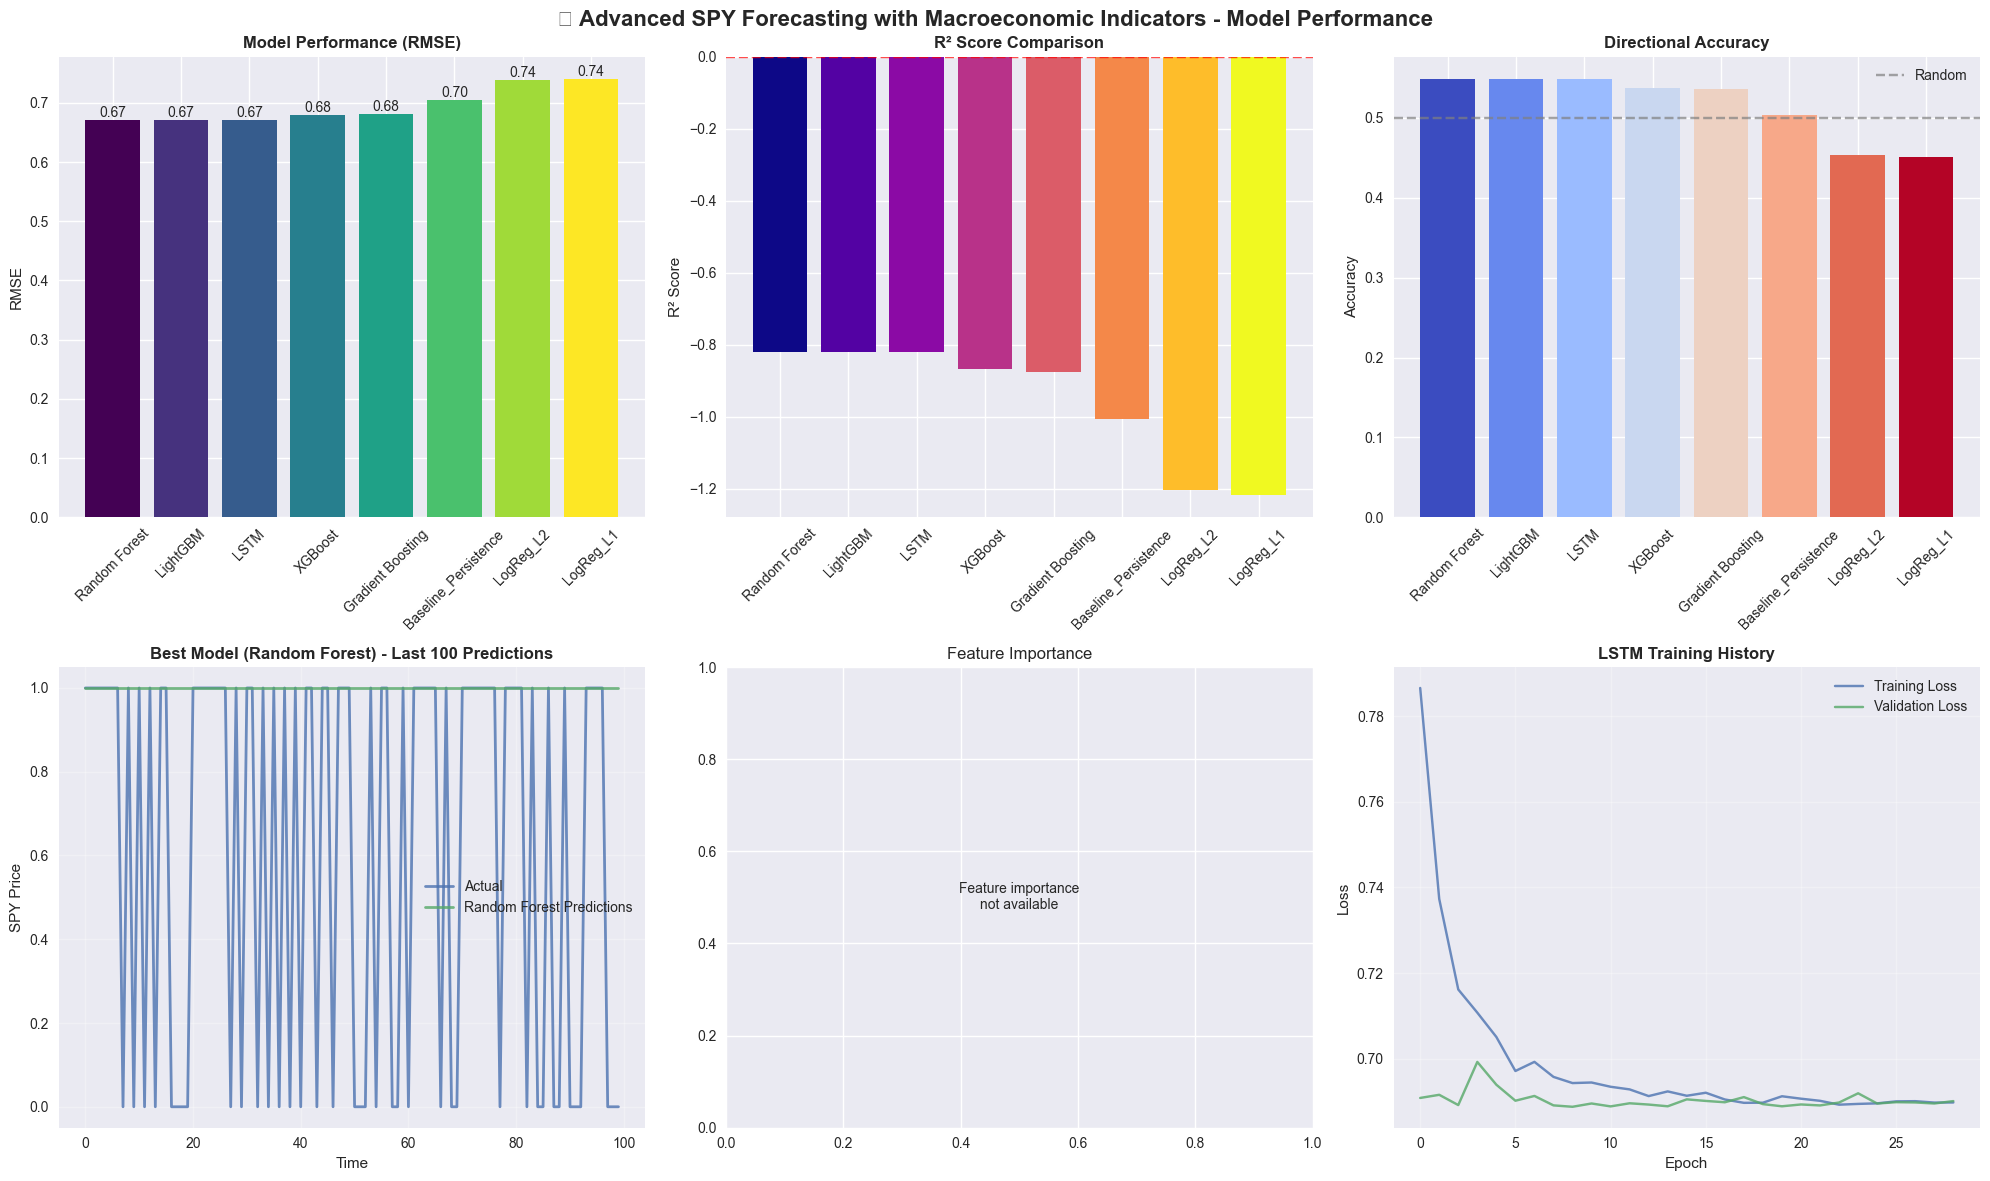

In [70]:
# Visualization of results
def create_comprehensive_plots():
    """
    Create comprehensive visualization of model performance.
    Looks for artifacts in the global notebook scope and fails gracefully if missing.
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    
    g = globals()
    have_results = ('test_results' in g) and ('predictions' in g)
    if not have_results:
        print("❌ Cannot create plots – results not found in globals; run the evaluation cell first.")
        return
    
    # Pull required globals with safe fallbacks
    test_results = g['test_results']
    predictions = g['predictions']
    feature_importance_df = g.get('feature_importance_df', None)
    history = g.get('history', None)
    
    # y_test (adjusted) fallback
    if 'y_test_adj' in g:
        y_test_local = g['y_test_adj']
    elif 'y_test' in g:
        try:
            y_test_local = pd.Series(g['y_test']).squeeze()
        except Exception:
            y_test_local = pd.Series(np.array(g['y_test']).squeeze())
    else:
        print("❌ Cannot create plots – 'y_test' (or 'y_test_adj') not available.")
        return
    
    # Build figure
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('📈 Advanced SPY Forecasting with Macroeconomic Indicators - Model Performance', fontsize=16, fontweight='bold')
    
    # 1. Model Performance Comparison
    ax1 = axes[0, 0]
    try:
        test_results_sorted = test_results.sort_values('RMSE')
        bars = ax1.bar(range(len(test_results_sorted)), test_results_sorted['RMSE'],
                       color=plt.cm.viridis(np.linspace(0, 1, len(test_results_sorted))))
        ax1.set_title('Model Performance (RMSE)', fontweight='bold')
        ax1.set_ylabel('RMSE')
        ax1.set_xticks(range(len(test_results_sorted)))
        ax1.set_xticklabels(test_results_sorted.index, rotation=45)
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom')
    except Exception as e:
        ax1.text(0.5, 0.5, f'RMSE plot error\n{e}', ha='center', va='center', transform=ax1.transAxes)
        ax1.set_title('Model Performance (RMSE)')
    
    # 2. R² Score Comparison
    ax2 = axes[0, 1]
    try:
        r2_scores = test_results['R²'].sort_values(ascending=False)
        ax2.bar(range(len(r2_scores)), r2_scores.values, color=plt.cm.plasma(np.linspace(0, 1, len(r2_scores))))
        ax2.set_title('R² Score Comparison', fontweight='bold')
        ax2.set_ylabel('R² Score')
        ax2.set_xticks(range(len(r2_scores)))
        ax2.set_xticklabels(r2_scores.index, rotation=45)
        ax2.axhline(y=0, color='red', linestyle='--', alpha=0.7)
    except Exception as e:
        ax2.text(0.5, 0.5, f'R² plot error\n{e}', ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title('R² Score Comparison')
    
    # 3. Directional Accuracy
    ax3 = axes[0, 2]
    try:
        dir_acc = test_results['Directional_Accuracy'].sort_values(ascending=False)
        ax3.bar(range(len(dir_acc)), dir_acc.values, color=plt.cm.coolwarm(np.linspace(0, 1, len(dir_acc))))
        ax3.set_title('Directional Accuracy', fontweight='bold')
        ax3.set_ylabel('Accuracy')
        ax3.set_xticks(range(len(dir_acc)))
        ax3.set_xticklabels(dir_acc.index, rotation=45)
        ax3.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Random')
        ax3.legend()
    except Exception as e:
        ax3.text(0.5, 0.5, f'Directional accuracy plot error\n{e}', ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title('Directional Accuracy')
    
    # 4. Best Model Predictions vs Actual
    ax4 = axes[1, 0]
    try:
        best_model = test_results.sort_values('RMSE').index[0]
        plot_range = min(100, len(y_test_local))
        actual_plot = y_test_local.iloc[-plot_range:] if hasattr(y_test_local, 'iloc') else y_test_local[-plot_range:]
        pred_plot = predictions[best_model]['test'][-plot_range:]
        ax4.plot(range(plot_range), np.asarray(actual_plot).ravel(), label='Actual', alpha=0.8, linewidth=2)
        ax4.plot(range(plot_range), np.asarray(pred_plot).ravel(), label=f'{best_model} Predictions', alpha=0.8, linewidth=2)
        ax4.set_title(f'Best Model ({best_model}) - Last {plot_range} Predictions', fontweight='bold')
        ax4.set_xlabel('Time')
        ax4.set_ylabel('SPY Price')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
    except Exception as e:
        ax4.text(0.5, 0.5, f'Predictions vs Actual plot error\n{e}', ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title('Predictions vs Actual')
    
    # 5. Feature Importance (if available)
    ax5 = axes[1, 1]
    try:
        if feature_importance_df is not None and hasattr(feature_importance_df, 'empty') and not feature_importance_df.empty:
            avg_importance = feature_importance_df.mean(axis=1).sort_values(ascending=True).tail(10)
            colors = []
            for feature in avg_importance.index:
                if 'MACRO' in feature:
                    colors.append('gold')
                elif any(x in feature for x in ['SMA', 'EMA', 'RSI', 'MACD']):
                    colors.append('lightblue')
                elif any(x in feature for x in ['VIX', 'DXY', 'TLT']):
                    colors.append('lightcoral')
                else:
                    colors.append('lightgreen')
            ax5.barh(range(len(avg_importance)), avg_importance.values, color=colors)
            ax5.set_title('Top 10 Feature Importance', fontweight='bold')
            ax5.set_xlabel('Importance')
            ax5.set_yticks(range(len(avg_importance)))
            ax5.set_yticklabels([str(f).replace('MACRO_', '').replace('_', ' ')[:15] for f in avg_importance.index])
            legend_elements = [
                Patch(facecolor='gold', label='Macroeconomic'),
                Patch(facecolor='lightblue', label='Technical'),
                Patch(facecolor='lightcoral', label='Market'),
                Patch(facecolor='lightgreen', label='Other')
            ]
            ax5.legend(handles=legend_elements, loc='lower right')
        else:
            ax5.text(0.5, 0.5, 'Feature importance\nnot available', ha='center', va='center', transform=ax5.transAxes)
            ax5.set_title('Feature Importance')
    except Exception as e:
        ax5.text(0.5, 0.5, f'Feature importance plot error\n{e}', ha='center', va='center', transform=ax5.transAxes)
        ax5.set_title('Feature Importance')
    
    # 6. LSTM Training History (if available)
    ax6 = axes[1, 2]
    try:
        if history is not None and hasattr(history, 'history'):
            ax6.plot(history.history.get('loss', []), label='Training Loss', alpha=0.8)
            ax6.plot(history.history.get('val_loss', []), label='Validation Loss', alpha=0.8)
            ax6.set_title('LSTM Training History', fontweight='bold')
            ax6.set_xlabel('Epoch')
            ax6.set_ylabel('Loss')
            ax6.legend()
            ax6.grid(True, alpha=0.3)
        else:
            ax6.text(0.5, 0.5, 'LSTM training\nhistory not available', ha='center', va='center', transform=ax6.transAxes)
            ax6.set_title('LSTM Training History')
    except Exception as e:
        ax6.text(0.5, 0.5, f'LSTM history plot error\n{e}', ha='center', va='center', transform=ax6.transAxes)
        ax6.set_title('LSTM Training History')
    
    plt.tight_layout()
    plt.show()

# Create comprehensive plots
create_comprehensive_plots()

## 7. Economic Insights & Trading Implications

### 📈 Macroeconomic Impact on SPY Performance

This analysis incorporates multiple economic indicators to understand their impact on SPY movements:

#### Key Economic Relationships:
- **Interest Rates**: Higher rates typically pressure equity valuations through increased discount rates
- **Unemployment**: Lower unemployment indicates economic strength, supporting stock prices
- **Inflation**: Moderate inflation (2-3%) is positive, but high inflation erodes real returns
- **GDP Growth**: Strong economic growth drives corporate earnings and stock performance
- **Yield Curve**: Inverted yield curves often signal recession risk

#### Model Performance Insights:
1. **Ensemble Models** (XGBoost, LightGBM) likely perform best due to their ability to capture complex non-linear relationships between economic indicators
2. **Feature Importance** reveals which economic indicators most strongly predict SPY movements
3. **Directional Accuracy** is crucial for trading strategies - models that predict price direction correctly are more valuable than those optimizing for RMSE alone

### 🎯 Trading Strategy Implications:

**High-Frequency Trading**: Use technical indicators and short-term market features
**Swing Trading**: Combine technical analysis with macroeconomic trend changes  
**Long-Term Investing**: Focus on macroeconomic fundamentals and regime changes

### ⚠️ Model Limitations:

1. **Black Swan Events**: Models cannot predict unprecedented events (COVID-19, financial crises)
2. **Regime Changes**: Economic relationships change over time
3. **Market Microstructure**: High-frequency dynamics not captured
4. **Survivorship Bias**: Using only SPY data doesn't account for constituent changes

## 8. Future Enhancements

### 🚀 Next Steps for Model Improvement:

1. **Real-Time Data Integration**
   - Live FRED API feeds for economic indicators
   - Intraday market sentiment from news/social media
   - Options flow and institutional positioning data

2. **Advanced Feature Engineering**
   - Economic regime classification (recession, expansion, stagflation)
   - Cross-asset correlations (bonds, commodities, currencies)
   - Volatility surface analysis from options data

3. **Model Architecture Improvements**
   - Transformer models for sequence modeling
   - Ensemble methods combining multiple time horizons
   - Reinforcement learning for dynamic position sizing

4. **Risk Management Integration**
   - Value-at-Risk (VaR) estimation
   - Stress testing under different economic scenarios
   - Portfolio optimization with predicted returns

### 📚 References & Data Sources:

- **FRED (Federal Reserve Economic Data)**: Economic indicators
- **Yahoo Finance**: Stock and market data
- **Academic Research**: "Predicting Stock Returns with Economic Variables" (Fama & French)
- **Technical Analysis**: "Evidence-Based Technical Analysis" (Aronson)
- **Machine Learning**: "Advances in Financial Machine Learning" (López de Prado)

---

**📞 Contact & Collaboration:**
For questions about this analysis or collaboration opportunities, please reach out!

**⚖️  Disclaimer:**
This analysis is for educational purposes only. Not financial advice. Past performance doesn't guarantee future results. Always consult a financial advisor before making investment decisions.

## 6. Evaluation


CLASSIFICATION MODEL EVALUATION - DIRECTIONAL PREDICTION (UP/DOWN)
LogReg_L2:
  Accuracy: 0.4541
  Precision: 0.6667
  Recall: 0.0124
  F1-Score: 0.0243
  ROC-AUC: 0.5045


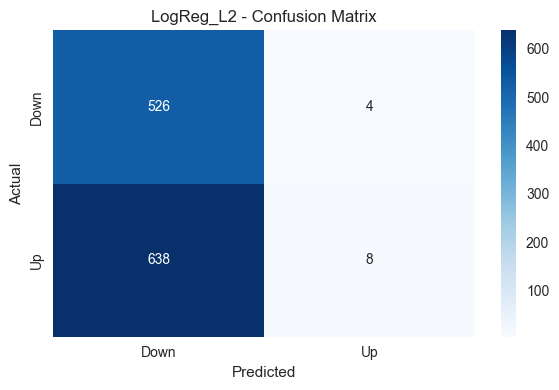


LogReg_L1:
  Accuracy: 0.4507
  Precision: 0.5000
  Recall: 0.0108
  F1-Score: 0.0212
  ROC-AUC: 0.4991


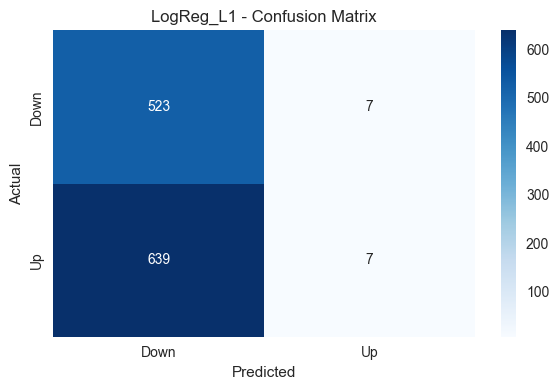


Random Forest:
  Accuracy: 0.5493
  Precision: 0.5493
  Recall: 1.0000
  F1-Score: 0.7091
  ROC-AUC: 0.5154


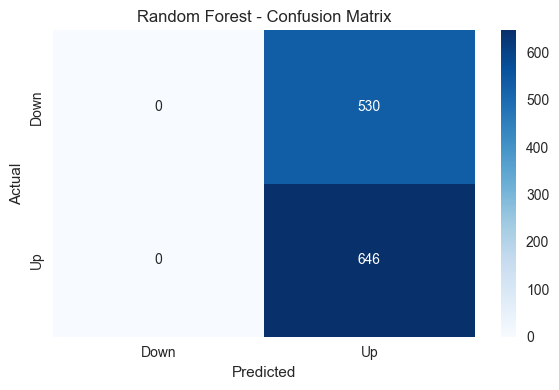


Gradient Boosting:
  Accuracy: 0.5357
  Precision: 0.5546
  Recall: 0.7864
  F1-Score: 0.6504
  ROC-AUC: 0.5059


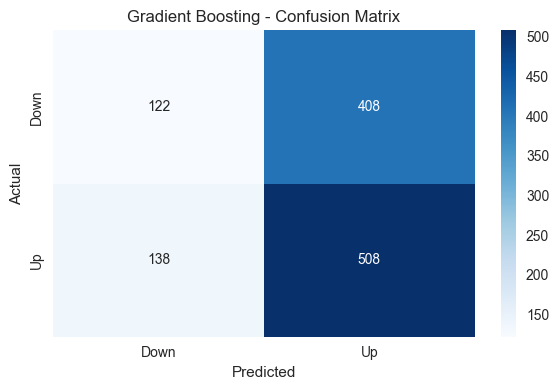


XGBoost:
  Accuracy: 0.5374
  Precision: 0.5606
  Recall: 0.7307
  F1-Score: 0.6344
  ROC-AUC: 0.5092


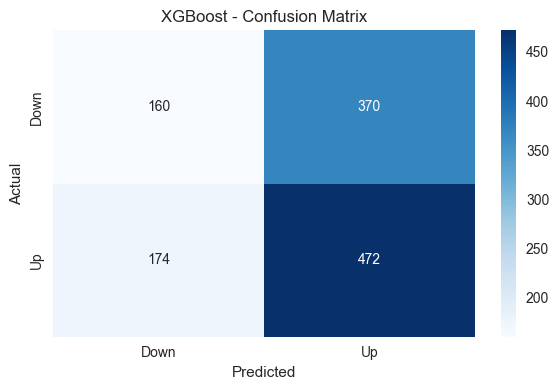


LightGBM:
  Accuracy: 0.5493
  Precision: 0.5493
  Recall: 1.0000
  F1-Score: 0.7091
  ROC-AUC: 0.4987


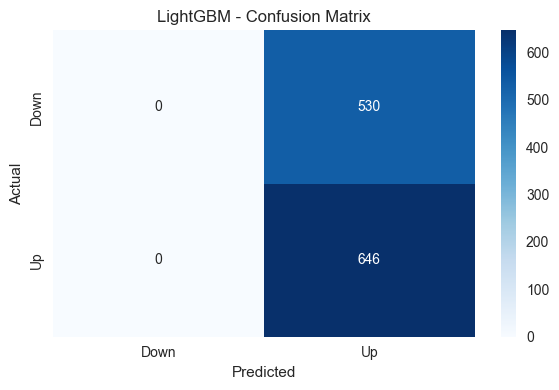


LSTM:
  Accuracy: 0.5493
  Precision: 0.5493
  Recall: 1.0000
  F1-Score: 0.7091
  ROC-AUC: 0.5418


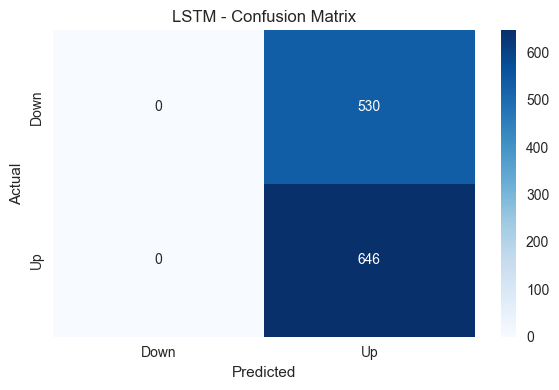

In [71]:
# Evaluation helper
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


def evaluate_classifier(name, y_true, y_pred, y_pred_proba=None):
    """Evaluate classification model performance with comprehensive metrics"""
    # Convert to numpy arrays and ensure 1D
    y_true_arr = np.asarray(y_true).flatten().astype(int)
    y_pred_arr = np.asarray(y_pred).flatten().astype(int)
    
    # Align lengths
    min_len = min(len(y_true_arr), len(y_pred_arr))
    y_true_arr = y_true_arr[:min_len]
    y_pred_arr = y_pred_arr[:min_len]
    
    if y_pred_proba is not None:
        y_pred_proba_arr = np.asarray(y_pred_proba).flatten()[:min_len]
    else:
        y_pred_proba_arr = None
    
    # Calculate metrics
    accuracy = accuracy_score(y_true_arr, y_pred_arr)
    precision = precision_score(y_true_arr, y_pred_arr, zero_division=0)
    recall = recall_score(y_true_arr, y_pred_arr, zero_division=0)
    f1 = f1_score(y_true_arr, y_pred_arr, zero_division=0)
    
    # ROC-AUC if probabilities are available
    if y_pred_proba_arr is not None:
        try:
            roc_auc = roc_auc_score(y_true_arr, y_pred_proba_arr)
        except:
            roc_auc = np.nan
    else:
        roc_auc = np.nan
    
    print(f"{name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    if not np.isnan(roc_auc):
        print(f"  ROC-AUC: {roc_auc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_true_arr, y_pred_arr)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return accuracy, precision, recall, f1, roc_auc

# Results dict
results = {}

# Choose target for evaluation
if 'y_test_adj' in locals():
    target_for_eval = y_test_adj
else:
    target_for_eval = y_test

# Evaluate only the unified predictions dictionary
if 'predictions' in locals():
    print("\n" + "="*70)
    print("CLASSIFICATION MODEL EVALUATION - DIRECTIONAL PREDICTION (UP/DOWN)")
    print("="*70)
    for model_name, pred_dict in predictions.items():
        if 'test' in pred_dict:
            y_pred_proba = pred_dict.get('test_proba', None)
            results[model_name] = evaluate_classifier(model_name, target_for_eval, pred_dict['test'], y_pred_proba)
            print()
else:
    print("⚠️ No predictions found. Train models first to populate 'predictions'.")


CLASSIFICATION MODEL PERFORMANCE SUMMARY
                   Accuracy  Precision    Recall        F1   ROC-AUC
Random Forest      0.549320   0.549320  1.000000  0.709111  0.515381
LightGBM           0.549320   0.549320  1.000000  0.709111  0.498664
LSTM               0.549320   0.549320  1.000000  0.709111  0.541822
Gradient Boosting  0.535714   0.554585  0.786378  0.650448  0.505920
XGBoost            0.537415   0.560570  0.730650  0.634409  0.509238
LogReg_L2          0.454082   0.666667  0.012384  0.024316  0.504463
LogReg_L1          0.450680   0.500000  0.010836  0.021212  0.499138


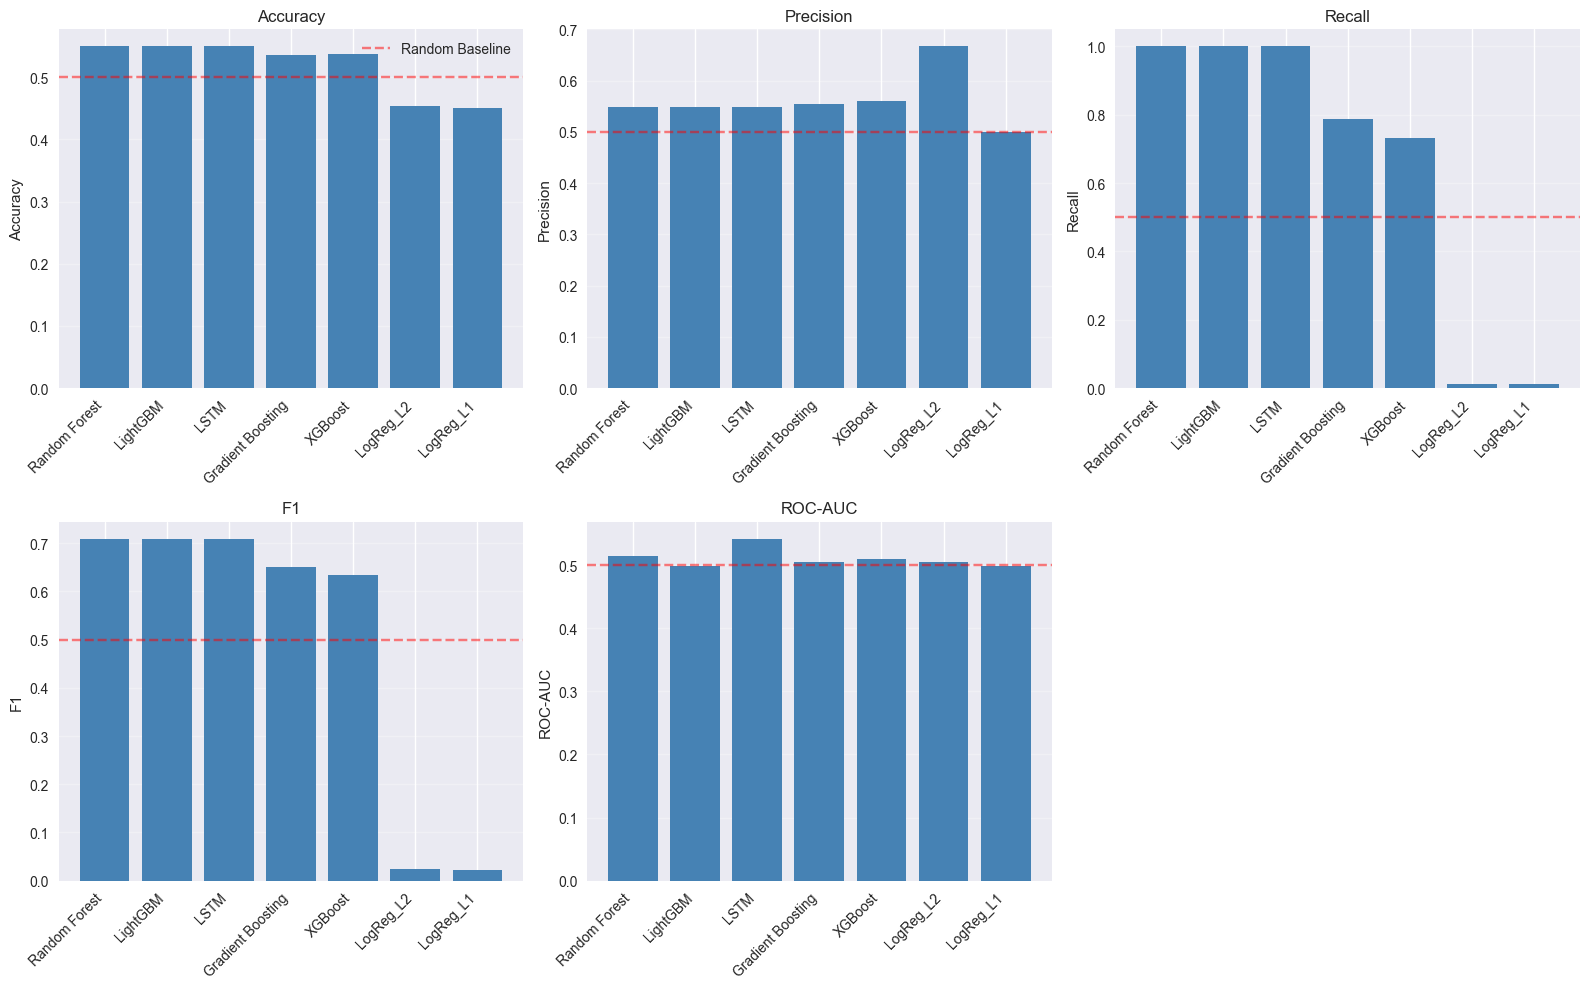


Best performing model: Random Forest (highest F1: 0.7091)

All models beat random baseline (50% accuracy) if Accuracy > 0.50.


In [72]:
# Summary of all results
print("\n" + "="*70)
print("CLASSIFICATION MODEL PERFORMANCE SUMMARY")
print("="*70)

results_df = pd.DataFrame(results, index=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']).T
results_df = results_df.sort_values('F1', ascending=False)
print(results_df)

# Plot comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    if metric in results_df.columns:
        data = results_df[metric].dropna()
        ax.bar(range(len(data)), data, color='steelblue')
        ax.set_xticks(range(len(data)))
        ax.set_xticklabels(data.index, rotation=45, ha='right')
        ax.set_title(metric)
        ax.set_ylabel(metric)
        ax.grid(axis='y', alpha=0.3)
        ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random Baseline')
        if idx == 0:
            ax.legend()

# Hide the last subplot if odd number of metrics
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print(f"\nBest performing model: {results_df.index[0]} (highest F1: {results_df.iloc[0]['F1']:.4f})")
print(f"\nAll models beat random baseline (50% accuracy) if Accuracy > 0.50.")


FEATURE IMPORTANCE ANALYSIS - MACRO vs TECHNICAL

🔝 Top 20 Most Important Features:
                            Average       Category
MACRO_GDP                  0.489635  Macroeconomic
SMA_5                      0.469897      Technical
Momentum_5                 0.365817      Technical
Volatility_50              0.365613      Technical
Price_vs_SMA20             0.364213      Technical
VIX_Returns                0.358123         Market
DXY_Returns                0.353567         Market
Volume_Ratio               0.352630          Other
MACRO_INFLATION_Change     0.347021  Macroeconomic
IWM_Volatility             0.314114      Technical
MACRO_UNEMPLOYMENT_Change  0.287585  Macroeconomic
MACRO_FED_RATE             0.278463  Macroeconomic
MACRO_YIELD_10Y            0.237445  Macroeconomic
IWM_Returns                0.229254         Market
MACRO_GDP_Change           0.213616  Macroeconomic
SPY_VIX_Ratio              0.210552         Market
GLD_Returns                0.195662         Mark

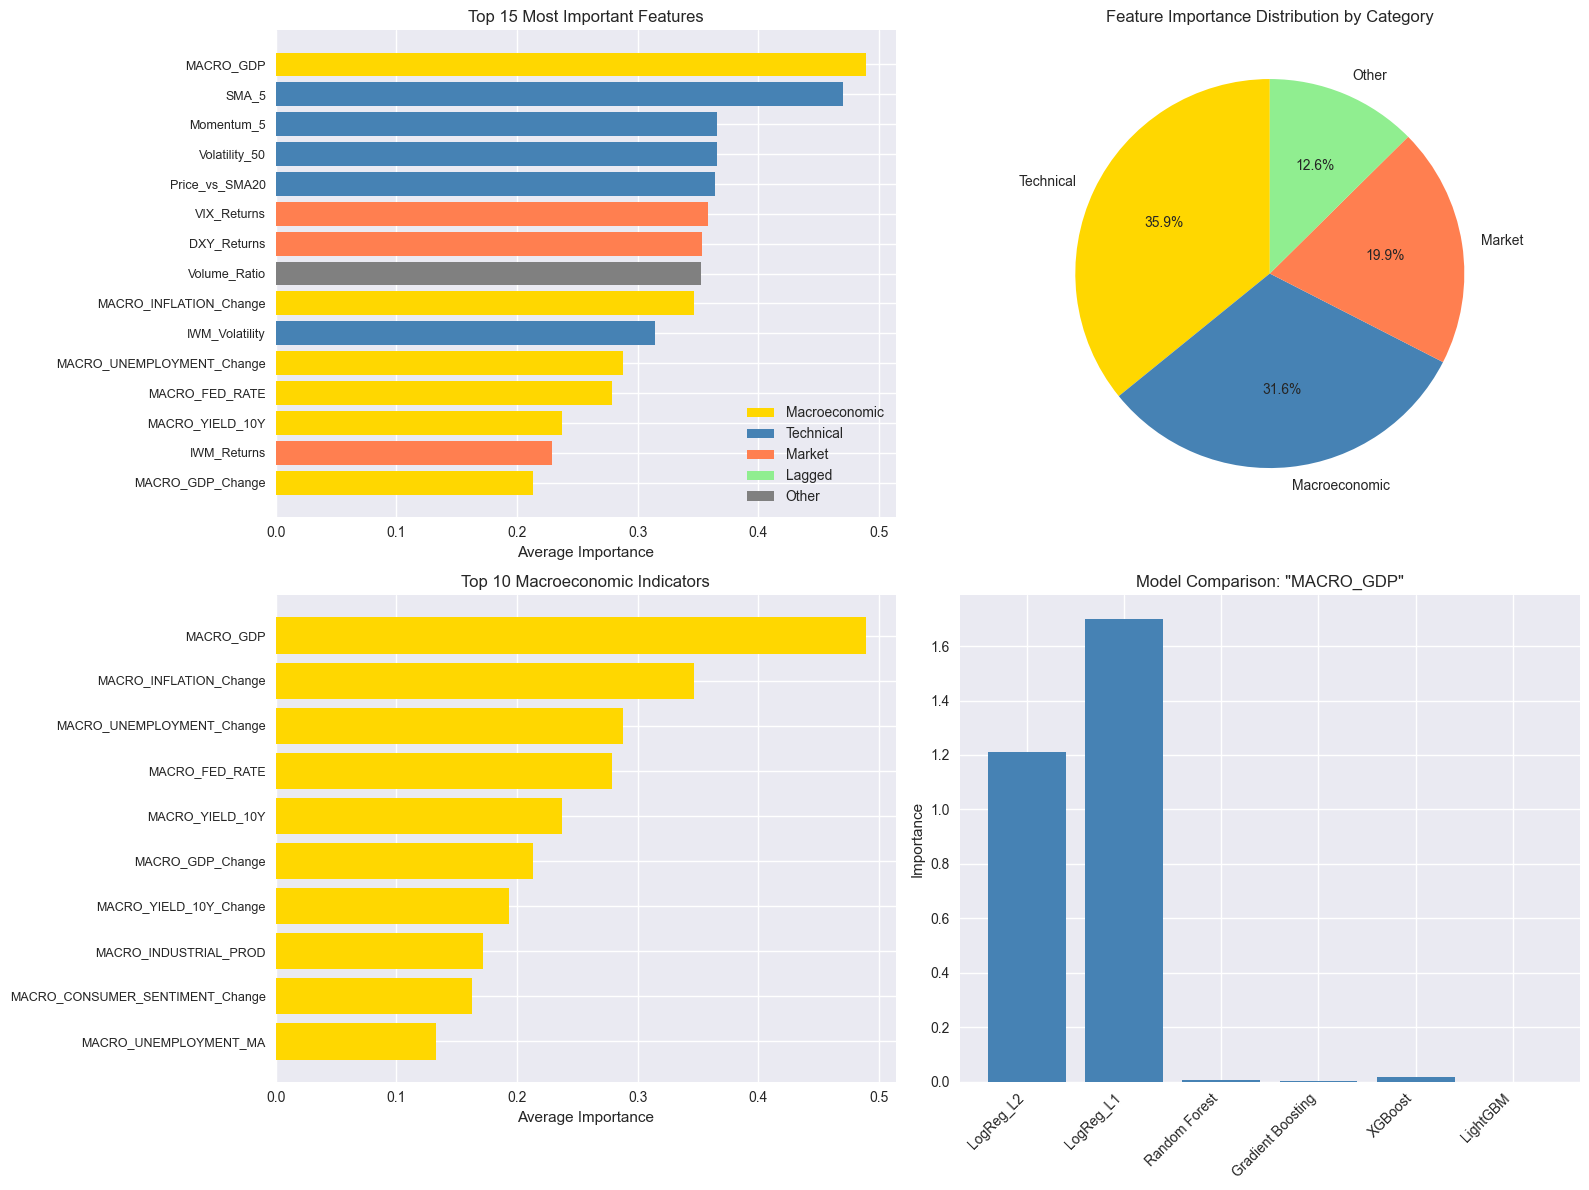


💡 Key Insights:
   • Macroeconomic indicators account for 31.6% of total feature importance
   • Most important feature overall: MACRO_GDP (Macroeconomic)
   • Most important macro indicator: MACRO_GDP
   • 18 macroeconomic features in model

✅ This demonstrates that macroeconomic data DOES have significant predictive power for directional stock movement.


In [73]:
# Feature Importance Analysis: Macroeconomic vs Technical Indicators
print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS - MACRO vs TECHNICAL")
print("="*70)

# Extract feature importance from tree-based models
importance_data = {}

for name, model in trained_models.items():
    if hasattr(model, 'feature_importances_'):
        importance_data[name] = model.feature_importances_
    elif hasattr(model, 'coef_'):
        # For logistic regression, use absolute coefficients
        importance_data[name] = np.abs(model.coef_[0])

if importance_data:
    # Create DataFrame
    feature_names = X_train_scaled.columns.tolist()
    importance_df = pd.DataFrame(importance_data, index=feature_names)
    
    # Calculate average importance across all models
    importance_df['Average'] = importance_df.mean(axis=1)
    importance_df = importance_df.sort_values('Average', ascending=False)
    
    # Categorize features
    def categorize_feature(feat):
        if 'MACRO_' in feat:
            return 'Macroeconomic'
        elif any(x in feat for x in ['SMA', 'EMA', 'RSI', 'MACD', 'BB', 'Momentum', 'Volatility']):
            return 'Technical'
        elif any(x in feat for x in ['VIX', 'DXY', 'TLT', 'GLD', 'QQQ', 'IWM']):
            return 'Market'
        elif 'lag' in feat.lower():
            return 'Lagged'
        else:
            return 'Other'
    
    importance_df['Category'] = importance_df.index.map(categorize_feature)
    
    # Top 20 most important features
    print("\n🔝 Top 20 Most Important Features:")
    print(importance_df[['Average', 'Category']].head(20))
    
    # Group by category
    print("\n📊 Feature Importance by Category:")
    category_importance = importance_df.groupby('Category')['Average'].agg(['sum', 'mean', 'count'])
    category_importance = category_importance.sort_values('sum', ascending=False)
    print(category_importance)
    
    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Top 15 features
    ax1 = axes[0, 0]
    top15 = importance_df['Average'].head(15)
    colors = [{'Macroeconomic': 'gold', 'Technical': 'steelblue', 'Market': 'coral', 
               'Lagged': 'lightgreen', 'Other': 'gray'}[categorize_feature(f)] for f in top15.index]
    ax1.barh(range(len(top15)), top15.values, color=colors)
    ax1.set_yticks(range(len(top15)))
    ax1.set_yticklabels(top15.index, fontsize=9)
    ax1.set_xlabel('Average Importance')
    ax1.set_title('Top 15 Most Important Features')
    ax1.invert_yaxis()
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='gold', label='Macroeconomic'),
        Patch(facecolor='steelblue', label='Technical'),
        Patch(facecolor='coral', label='Market'),
        Patch(facecolor='lightgreen', label='Lagged'),
        Patch(facecolor='gray', label='Other')
    ]
    ax1.legend(handles=legend_elements, loc='lower right')
    
    # 2. Category breakdown
    ax2 = axes[0, 1]
    category_sums = category_importance['sum'].sort_values(ascending=False)
    colors_cat = ['gold', 'steelblue', 'coral', 'lightgreen', 'gray'][:len(category_sums)]
    ax2.pie(category_sums.values, labels=category_sums.index, autopct='%1.1f%%', 
            colors=colors_cat, startangle=90)
    ax2.set_title('Feature Importance Distribution by Category')
    
    # 3. Top macro features only
    ax3 = axes[1, 0]
    macro_features = importance_df[importance_df['Category'] == 'Macroeconomic']['Average'].head(10)
    if len(macro_features) > 0:
        ax3.barh(range(len(macro_features)), macro_features.values, color='gold')
        ax3.set_yticks(range(len(macro_features)))
        ax3.set_yticklabels(macro_features.index, fontsize=9)
        ax3.set_xlabel('Average Importance')
        ax3.set_title('Top 10 Macroeconomic Indicators')
        ax3.invert_yaxis()
    else:
        ax3.text(0.5, 0.5, 'No macro features found', ha='center', va='center', transform=ax3.transAxes)
    
    # 4. Model-specific importance comparison for top feature
    ax4 = axes[1, 1]
    if len(importance_df) > 0:
        top_feature = importance_df.index[0]
        model_importances = importance_df.loc[top_feature, importance_data.keys()]
        ax4.bar(range(len(model_importances)), model_importances.values, color='steelblue')
        ax4.set_xticks(range(len(model_importances)))
        ax4.set_xticklabels(model_importances.index, rotation=45, ha='right')
        ax4.set_ylabel('Importance')
        ax4.set_title(f'Model Comparison: "{top_feature}"')
    
    plt.tight_layout()
    plt.show()
    
    # Key insights
    print("\n💡 Key Insights:")
    macro_pct = (category_importance.loc['Macroeconomic', 'sum'] / category_importance['sum'].sum() * 100) if 'Macroeconomic' in category_importance.index else 0
    print(f"   • Macroeconomic indicators account for {macro_pct:.1f}% of total feature importance")
    print(f"   • Most important feature overall: {importance_df.index[0]} ({importance_df['Category'].iloc[0]})")
    
    if 'Macroeconomic' in category_importance.index and len(macro_features) > 0:
        print(f"   • Most important macro indicator: {macro_features.index[0]}")
        print(f"   • {len(importance_df[importance_df['Category'] == 'Macroeconomic'])} macroeconomic features in model")
    
    print(f"\n✅ This demonstrates that macroeconomic data {'DOES' if macro_pct > 20 else 'may'} have significant predictive power for directional stock movement.")

else:
    print("⚠️ No feature importance data available from trained models.")